# Computer Vision 
## Notebook 5 — RF-DETR: Training, Evaluation & Error Analysis

| | |
|---|---|
| **Dataset** | **VisioDECT — Scenario-Based Multi-Drone Detection** (as prepared in Notebook 1) |
| **Source** | https://www.kaggle.com/datasets/simeonajakwe/visiodect-for-scenario-based-multi-drone-detection |
| **Input** | Notebook 1 committed output: `visiodect_yolo/` (14,422 / 3,090 / 3,091 leakage-free splits) |
| **Model** | RF-DETR-**nano**, 20 epochs @ **448 px** — stepped down from 640 after a measured 47 min/epoch dry run; fp16 forced over T4-emulated bf16 (CONFIG) |

**Covers Tasks for RF-DETR:** CONFIG → environment → **YOLO→COCO conversion** of
Notebook 1's splits (assignment §6.5 step 3) → 1-epoch dry run → full training (20 epochs)
with **loss-component and mAP curves** → test-split evaluation via COCOeval (mAP@50,
mAP@50:95, P, R, F1, FPS) → error analysis with full-frame + zoom panels (≥3 FN, ≥3 FP, TP,
per-scenario breakdown) → best checkpoint saved to a clearly named `/kaggle/working/` path
for cross-model comparison against the YOLO notebooks.

## 0. How to Run This Notebook on Kaggle
1. **Create the notebook**: Kaggle → *Create* → *New Notebook* → File → Import Notebook.
2. **Settings (right panel)**: Accelerator = **GPU T4 x2** (or P100); Internet = **On**
   (needed to `pip install rfdetr …` and to download the pretrained `rf-detr-nano.pth`
   from Roboflow's weight host).
3. **Attach Notebook 1's output**: *Add Input* → *Your Work* → committed **Notebook 1** →
   its **Output**. `visiodect_yolo/` must appear under `/kaggle/input/<nb1-slug>/`.
   Section 3 verifies it is the **final** version (CSV label recovery) and fails loudly on
   the old one. Do not attach the raw VisioDECT dataset.
4. **For the cross-model comparison (§8.1)**: also attach the outputs of **Notebooks 3 and
   4** — their `model_comparison/*.json` files (YOLOv12, YOLOv26) are merged automatically.
5. Fill in the **group fields** in the title and CONFIG cells.
6. **Run all**. If the very first import of `rfdetr` fails after installation, restart the
   session (Run → Restart & clear cell outputs) and run all again — a known Kaggle quirk
   the course demo also documents.
7. Watch the Section 4 dry run: it extrapolates the 20-epoch wall time — proceed if under
   ~7 h. (An earlier 640 px attempt measured 47+ min/epoch; the current 448 px + fp16
   config exists because of that measurement.) If still over budget, drop `RESOLUTION`
   to 384 with a documented note; keep `EPOCHS ≥ 20` (assignment minimum).
8. **Session strategy (important)**: 20 epochs at 384 px measures ~10-11.5 h on a T4 — too
   close to Kaggle's 12 h kill for a blind *Save & Run All* commit (an earlier commit was
   lost exactly this way). Instead: **run interactively** (Run All), watch the per-epoch
   pace, and when the last cell finishes use **Save Version → Quick Save → include
   outputs** — this snapshots the executed notebook without re-running anything. Then set
   visibility **Public** and test the link in an incognito window.

## 1. CONFIG
Every §6.5-required parameter is declared here: variant + justification, epochs (≥20),
input resolution, **backbone LR vs head LR**, gradient-clip norm, warmup, and how the
frozen-backbone recommendation is realised in this package version.

In [ ]:
# =============================== CONFIG ===============================

# ---- model choice ------------------------------------------------------
VARIANT = "nano"      # RF-DETR variant. Justification: the assignment table maps
                      # 8k-20k images to "nano or base", and the measured YOLO dry
                      # runs on this dataset showed single-T4 budgets are tight
                      # (YOLOv12-s took 464 min for 60 epochs); nano's smaller
                      # DINOv2-style backbone keeps 20 DETR epochs inside the
                      # session. Trade-off vs base (viva Q2): base = stronger
                      # pretrained features & higher AP ceiling, ~2-3x compute.
EPOCHS  = 20          # assignment minimum for RF-DETR. Budget decision (from the
                      # measured 35.6 min/epoch bf16 run): after the fp16 fix the
                      # dry run below re-measures and prints the verdict —
                      #   dry <= 29 min/epoch -> keep 20 (fits ~10.3 h incl. dry)
                      #   29-34 min/epoch     -> set the printed max that fits
                      #   >= 35 min/epoch     -> set 15 (documented reduction per
                      #      assignment §10: 21x35.6 min = 12.6 h exceeds Kaggle's
                      #      12 h cap, and the 11-epoch run's EMA-mAP gains had
                      #      already fallen to +0.001..0.006/epoch by epochs 8-10).
RESOLUTION = 384      # MEASURED decision chain (assignment §10): 640 px measured
                      # 47+ min/epoch (attention is quadratic in tokens: 1,600 @640);
                      # 384 px (nano's NATIVE resolution, 576 tokens, div-64)
                      # measured ~7.3 h for dry run + 11 epochs + full evaluation
                      # on a T4 — the only setting that fits 20 epochs in a session.
                      # Caveat for the viva: YOLO ran @640 vs RF-DETR @384 (recorded
                      # in the comparison JSON's imgsz); median 59 px drones shrink
                      # to ~9-12 px here, so a stronger small-object FN tail is an
                      # EXPECTED finding, not a bug.
RESUME = False
SKIP_DRY_RUN = False  # RE-MEASURE: the fp16 fix changes per-epoch time, so the
                      # old measurements (640/bf16: 47+ min; 384/bf16: 35.6 min)
                      # no longer apply. Set True only after fp16 is confirmed.

# ---- optimisation (assignment §4.3.3 values) -----------------------------
LR          = 1e-4    # detection-head LR
LR_ENCODER  = 1e-5    # backbone LR = 10x LOWER than the head (assignment-mandated;
                      # viva Q3: equal LRs would let large early gradients destroy
                      # the pretrained DINOv2-style features).
CLIP_MAX_NORM = 0.1   # gradient clipping to stabilise the transformer decoder
WARMUP_EPOCHS = 2     # ~10% of the 20-epoch run (assignment's 3-5 assumes 50 epochs)
# Frozen-backbone note: this pip release exposes no freeze-epochs switch; the
# freeze-then-unfreeze intent is realised via LR_ENCODER (10x lower) plus the
# library's per-layer LR decay, which keeps early backbone updates near-zero.
# The exact accepted train() arguments are printed in Section 5 for the viva.
EARLY_STOPPING, ES_PATIENCE = True, 5

# ---- batching (T4, 640 px) -----------------------------------------------
BATCH_SIZE       = 8  # 448 px frees the VRAM for larger batches -> half the
GRAD_ACCUM_STEPS = 2  # forward passes per step; effective batch stays 16,
                      # matching the YOLO notebooks
AMP_DTYPE        = "fp16"      # MEASURED bug-fix chain: the first attempt passed
                      # "float16", which rfdetr's pydantic config REJECTED with a
                      # warning ("expected one of 'auto','bf16','fp16'") and fell
                      # back to auto -> bfloat16 -> T4 emulation (the 11-epoch run
                      # logged "Using bfloat16 AMP" and cost 35.6 min/epoch).
                      # "fp16" is the accepted spelling and engages the T4's real
                      # tensor cores. VERIFY in the training log: it must say
                      # "Using float16/fp16 Automatic Mixed Precision" — if it
                      # still says bfloat16, stop and investigate before burning
                      # a session.
NUM_WORKERS      = 4

# ---- inference / evaluation ------------------------------------------------
CONF_PREDICT = 0.05   # predictions are collected ONCE at a low threshold so both
                      # COCOeval (needs all scores) and the conf sweep reuse them
CONF_EVAL    = 0.25   # assignment default for P/R/F1 and error analysis
CONF_SWEEP   = [0.25, 0.40, 0.50]

# ---- paths -------------------------------------------------------------------
DATASET_DIR_MANUAL = None          # e.g. Path("/kaggle/input/<nb1-slug>/visiodect_yolo")
WORK_ROOT  = "/kaggle/working"
COCO_ROOT  = f"{WORK_ROOT}/visiodect_coco"          # YOLO->COCO converted splits
RUN_OUT    = f"{WORK_ROOT}/runs_rfdetr/rfdetr_{VARIANT}_visiodect"
DRY_OUT    = f"{WORK_ROOT}/runs_rfdetr/rfdetr_{VARIANT}_dryrun"

# ---- clearly named artifacts for cross-model comparison (shared contract) ----
CKPT_PATH       = f"{WORK_ROOT}/checkpoints/rfdetr_{VARIANT}_best.pth"
COMPARISON_JSON = f"{WORK_ROOT}/model_comparison/rfdetr.json"
METRICS_CSV     = f"{WORK_ROOT}/rfdetr_test_metrics.csv"
PER_CLASS_CSV   = f"{WORK_ROOT}/rfdetr_per_class_metrics.csv"
ERROR_CSV       = f"{WORK_ROOT}/rfdetr_error_analysis.csv"
CURVES_PNG      = f"{WORK_ROOT}/rfdetr_training_curves.png"

SEED = 42
print(f"CONFIG | RF-DETR-{VARIANT} | epochs={EPOCHS} | res={RESOLUTION} | "
      f"batch {BATCH_SIZE}x{GRAD_ACCUM_STEPS} | head lr {LR} / backbone lr {LR_ENCODER}"
      f"\ncheckpoint -> {CKPT_PATH}")


CONFIG | RF-DETR-nano | epochs=20 | res=384 | batch 8x2 | head lr 0.0001 / backbone lr 1e-05
checkpoint -> /kaggle/working/checkpoints/rfdetr_nano_best.pth


## 2. Environment Setup
`faster-coco-eval` is **required** — RF-DETR's validation uses TorchMetrics'
MeanAveragePrecision, which selects that backend on Kaggle (the course demo documents the
crash without it). If the `rfdetr` import fails right after installing, restart the session
and run all again.

In [2]:
!pip install -q -U "rfdetr[train]" supervision pycocotools torchmetrics faster-coco-eval
# NOTE: the [train] extra is REQUIRED — base rfdetr ships inference only
# (training imports pytorch_lightning, which [train] provides).

import os, json, math, time, random, shutil
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm
import torch

try:
    import faster_coco_eval  # noqa: F401  (import check per the course demo)
    from rfdetr import RFDETRNano, RFDETRBase
    import rfdetr as _rfdetr_pkg
except Exception as e:
    raise RuntimeError("rfdetr / faster-coco-eval import failed — restart the Kaggle "
                       "session and rerun (known first-install quirk).") from e
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

RFDETR_CLASS = {"nano": RFDETRNano, "base": RFDETRBase}[VARIANT]

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
plt.rcParams.update({"figure.dpi": 140, "font.size": 12,
                     "axes.titlesize": 12, "axes.labelsize": 11})   # NB5: largest plots yet

print("rfdetr:", getattr(_rfdetr_pkg, "__version__", "installed"),
      "| torch:", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      "| GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "-")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.1/588.1 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 406.3/406.3 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 117.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 40.1 MB/s eta 0:00:00
rfdetr: installed | torch: 2.10.0+cu128 | CUDA: True | GPU: Tesla T4


/usr/local/lib/python3.12/dist-packages/rfdetr/models/weights.py:258: FutureWarning: target=True is deprecated since `v0.8`; use `TargetMode.ARGS_REMAP` instead. Will be removed in `v1.0`.
  @deprecated(target=True, args_mapping={"train_config": None}, deprecated_in="1.7.0", remove_in="1.9.0", num_warns=-1)


## 3. Locate Notebook 1's Splits, Verify, and Convert to COCO — 
RF-DETR consumes a **Roboflow-style COCO directory**: `train/`, `valid/`, `test/` folders
(note: `valid`, not `val`) each holding the images plus a `_annotations.coco.json`. The
converter below (per the course demo) symlinks images to avoid duplicating 2+ GB and
converts Notebook 1's YOLO labels to COCO xywh boxes with 0-based category ids.

In [3]:
def find_splits_root():
    if DATASET_DIR_MANUAL is not None:
        p = Path(DATASET_DIR_MANUAL)
        if (p / "train" / "images").exists():
            return p
        raise FileNotFoundError(f"Manual path is not a YOLO root: {p}")
    base = Path("/kaggle/input")
    stack, depth = [(base, 0)], 4
    while stack:
        d, dep = stack.pop()
        if d.name == "visiodect_yolo" and (d / "train" / "images").exists():
            return d
        if dep < depth:
            try:
                stack += [(c, dep + 1) for c in d.iterdir() if c.is_dir()]
            except (PermissionError, OSError):
                pass
    raise FileNotFoundError(
        "visiodect_yolo/ not found under /kaggle/input. Attach Notebook 1's OUTPUT "
        "(Add Input -> Your Work -> Notebook 1) or set DATASET_DIR_MANUAL.")

DATASET_ROOT = find_splits_root()
print("Splits root:", DATASET_ROOT)

# class names from Notebook 1's yaml (source of truth for indices)
import yaml as _yaml
nb1_yaml = _yaml.safe_load((DATASET_ROOT / "data.yaml").read_text())
CLASS_NAMES = list(nb1_yaml["names"])
assert len(CLASS_NAMES) == int(nb1_yaml["nc"]) == 6, (CLASS_NAMES, nb1_yaml.get("nc"))
print("Classes:", CLASS_NAMES)

DATA_YAML = Path(WORK_ROOT) / "data.yaml"
DATA_YAML.write_text(
    f"path: {DATASET_ROOT}\ntrain: train/images\nval: val/images\n"
    f"test: test/images\nnc: {len(CLASS_NAMES)}\nnames: {CLASS_NAMES}\n")
print("\nRegenerated", DATA_YAML, ":\n" + DATA_YAML.read_text())

# NB1's measured EDA, if shipped alongside (used for viva-ready printouts)
eda_path = DATASET_ROOT.parent / "eda_summary.json"
EDA = json.loads(eda_path.read_text()) if eda_path.exists() else {}
if EDA:
    print("NB1 eda_summary.json loaded | per-split counts:", EDA.get("per_split_counts"))


Splits root: /kaggle/input/notebooks/ahnafahmed11/cse445notebook1-datasetexploration-preprocessing/visiodect_yolo
Classes: ['Anafi', 'DJI_FPV', 'DJI_Phantom', 'EFT_E410S', 'Mavic_Air', 'Mavic_Enterprise']

Regenerated /kaggle/working/data.yaml :
path: /kaggle/input/notebooks/ahnafahmed11/cse445notebook1-datasetexploration-preprocessing/visiodect_yolo
train: train/images
val: val/images
test: test/images
nc: 6
names: ['Anafi', 'DJI_FPV', 'DJI_Phantom', 'EFT_E410S', 'Mavic_Air', 'Mavic_Enterprise']

NB1 eda_summary.json loaded | per-split counts: {'train': 14422, 'test': 3091, 'val': 3090}


In [4]:
# ---- split verification against Notebook 1 ---------------------------------
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
split_imgs = {}
for s in ["train", "val", "test"]:
    imgs = sorted(p for p in (DATASET_ROOT / s / "images").iterdir()
                  if p.suffix.lower() in IMG_EXTS)
    lbls = list((DATASET_ROOT / s / "labels").glob("*.txt"))
    split_imgs[s] = imgs
    print(f"{s:<5}: {len(imgs):,} images | {len(lbls):,} labels")
    assert len(imgs) == len(lbls), f"image/label count mismatch in {s}"

# guard (dataset history): the OLD Notebook 1 output exported unlabeled frames as
# EMPTY label files (false backgrounds). The final Notebook 1 excludes them, so any
# zero-byte label here means the wrong version is attached.
empty_lbls = [f for s in ["train", "val", "test"]
              for f in (DATASET_ROOT / s / "labels").glob("*.txt")
              if f.stat().st_size == 0]
if empty_lbls:
    raise RuntimeError(
        f"{len(empty_lbls)} EMPTY label files detected (e.g. {empty_lbls[0].name}). "
        "This is the OLD Notebook 1 output from before the CSV annotation-gap "
        "recovery/exclusion. Attach the FINAL committed Notebook 1 output and rerun.")
print("✔ No empty label files — final Notebook 1 output confirmed")

if EDA.get("per_split_counts"):
    for s in ["train", "val", "test"]:
        assert len(split_imgs[s]) == EDA["per_split_counts"][s], \
            f"{s} count differs from Notebook 1 commit!"
    print("✔ Split counts match Notebook 1's committed eda_summary.json")

# exported filenames encode class & scenario: "<Class>_<scenario>_<orig>"
SCENARIOS = ["cloudy", "evening", "sunny"]
def parse_stem(stem):
    for cname in sorted(CLASS_NAMES, key=len, reverse=True):
        if stem.startswith(cname + "_"):
            rest = stem[len(cname) + 1:]
            scen = rest.split("_")[0]
            return cname, (scen if scen in SCENARIOS else "unknown")
    return "unknown", "unknown"

meta = pd.DataFrame([{"split": s, "image": str(p), "stem": p.stem,
                      **dict(zip(["class_name", "scenario"], parse_stem(p.stem)))}
                     for s in split_imgs for p in split_imgs[s]])
display(meta.groupby(["split", "class_name"]).size().unstack(fill_value=0))
assert (meta.class_name != "unknown").all() and (meta.scenario != "unknown").all()
print("✔ class & scenario parsed from every filename (enables per-scenario error analysis)")


train: 14,422 images | 14,422 labels
val  : 3,090 images | 3,090 labels
test : 3,091 images | 3,091 labels
✔ No empty label files — final Notebook 1 output confirmed
✔ Split counts match Notebook 1's committed eda_summary.json


class_name,Anafi,DJI_FPV,DJI_Phantom,EFT_E410S,Mavic_Air,Mavic_Enterprise
split,,,,,,
test,506,516,495,533,529,512
train,2362,2407,2310,2486,2464,2393
val,507,516,495,533,526,513


✔ class & scenario parsed from every filename (enables per-scenario error analysis)


In [5]:
# ---- YOLO -> COCO conversion (course-demo pattern; val -> "valid") -----------
def yolo_to_coco_bbox(cx, cy, w, h, W, H):
    x = max(0.0, min((cx - w/2) * W, W - 1)); y = max(0.0, min((cy - h/2) * H, H - 1))
    bw = max(1.0, min(w * W, W - x));         bh = max(1.0, min(h * H, H - y))
    return [float(x), float(y), float(bw), float(bh)]

def safe_link_or_copy(src, dst):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        return
    try:
        os.symlink(src, dst)
    except Exception:
        shutil.copy2(src, dst)

SPLIT_MAP = {"train": "train", "val": "valid", "test": "test"}   # RF-DETR wants "valid"
coco_root = Path(COCO_ROOT)
if coco_root.exists():
    shutil.rmtree(coco_root)

conv_report, name2id, multi_ann = [], {}, []
for src_split, dst_split in SPLIT_MAP.items():
    out_dir = coco_root / dst_split
    out_dir.mkdir(parents=True, exist_ok=True)
    images, annots, ann_id = [], [], 1
    id_map = {}
    for img_id, img_path in enumerate(
            tqdm(split_imgs[src_split], desc=f"{src_split} -> {dst_split}"), start=1):
        with Image.open(img_path) as im:
            W, H = im.size
        safe_link_or_copy(img_path, out_dir / img_path.name)
        images.append({"id": img_id, "file_name": img_path.name, "width": W, "height": H})
        id_map[img_path.name] = img_id
        lbl = Path(str(img_path).replace("/images/", "/labels/")).with_suffix(".txt")
        n_boxes = 0
        for ln in lbl.read_text().splitlines():
            t = ln.split()
            if len(t) == 5:
                cid, cx, cy, w, h = int(t[0]), *map(float, t[1:])
                bbox = yolo_to_coco_bbox(cx, cy, w, h, W, H)
                annots.append({"id": ann_id, "image_id": img_id, "category_id": cid,
                               "bbox": bbox, "area": bbox[2]*bbox[3], "iscrowd": 0})
                ann_id += 1; n_boxes += 1
        if n_boxes != 1:
            multi_ann.append({"split": dst_split, "image": img_path.name,
                              "boxes": n_boxes,
                              "box_sizes_px": [f"{a['bbox'][2]:.0f}x{a['bbox'][3]:.0f}"
                                               for a in annots[-n_boxes:]] if n_boxes else []})
    cats = [{"id": i, "name": n, "supercategory": "drone"}
            for i, n in enumerate(CLASS_NAMES)]
    (out_dir / "_annotations.coco.json").write_text(json.dumps(
        {"info": {"description": f"VisioDECT {dst_split} (from Notebook 1 YOLO splits)"},
         "licenses": [], "images": images, "annotations": annots, "categories": cats}))
    name2id[dst_split] = id_map
    conv_report.append({"split": dst_split, "images": len(images), "annotations": len(annots)})

display(pd.DataFrame(conv_report))
# True integrity requirement: every image carries AT LEAST one box (Notebook 1
# excluded all unlabeled frames). A handful of images legitimately carry a second
# box: Notebook 1's CSV recovery preserved duplicate annotation rows from the
# Anafi-cloudy CSV, whose second row is a degenerate ~1-2 px artifact box next to
# the real drone. They are KEPT so RF-DETR trains on exactly the same labels as
# the YOLO notebooks (fair comparison); the forensic report below documents them.
assert all(r["annotations"] >= r["images"] for r in conv_report), \
    "some image has ZERO annotations — wrong Notebook 1 output attached?"
zero = [m for m in multi_ann if m["boxes"] == 0]
assert not zero, f"images with no boxes: {zero[:5]}"
if multi_ann:
    print(f"Images with more than one annotation: {len(multi_ann)} "
          "(duplicate CSV rows preserved by Notebook 1 — see box sizes; "
          "the ~1px entries are annotation-tool artifacts):")
    display(pd.DataFrame(multi_ann))
print("✔ COCO conversion complete — every image has >=1 box; "
      f"{sum(r['annotations'] for r in conv_report):,} annotations for "
      f"{sum(r['images'] for r in conv_report):,} images")


train -> train:   0%|          | 0/14422 [00:00<?, ?it/s]

val -> valid:   0%|          | 0/3090 [00:00<?, ?it/s]

test -> test:   0%|          | 0/3091 [00:00<?, ?it/s]

,split,images,annotations
0,train,14422,14424
1,valid,3090,3090
2,test,3091,3092


Images with more than one annotation: 3 (duplicate CSV rows preserved by Notebook 1 — see box sizes; the ~1px entries are annotation-tool artifacts):


,split,image,boxes,box_sizes_px
0,train,Anafi_cloudy_Anafi_Extended_Cloudy (901).jpg,2,"[60x18, 1x2]"
1,train,DJI_Phantom_cloudy_Dji_pantom_cloudy (737).jpg,2,"[118x81, 8x3]"
2,test,Anafi_cloudy_Anafi_Extended_Cloudy (1105).jpg,2,"[46x33, 1x1]"


✔ COCO conversion complete — every image has >=1 box; 20,606 annotations for 20,603 images


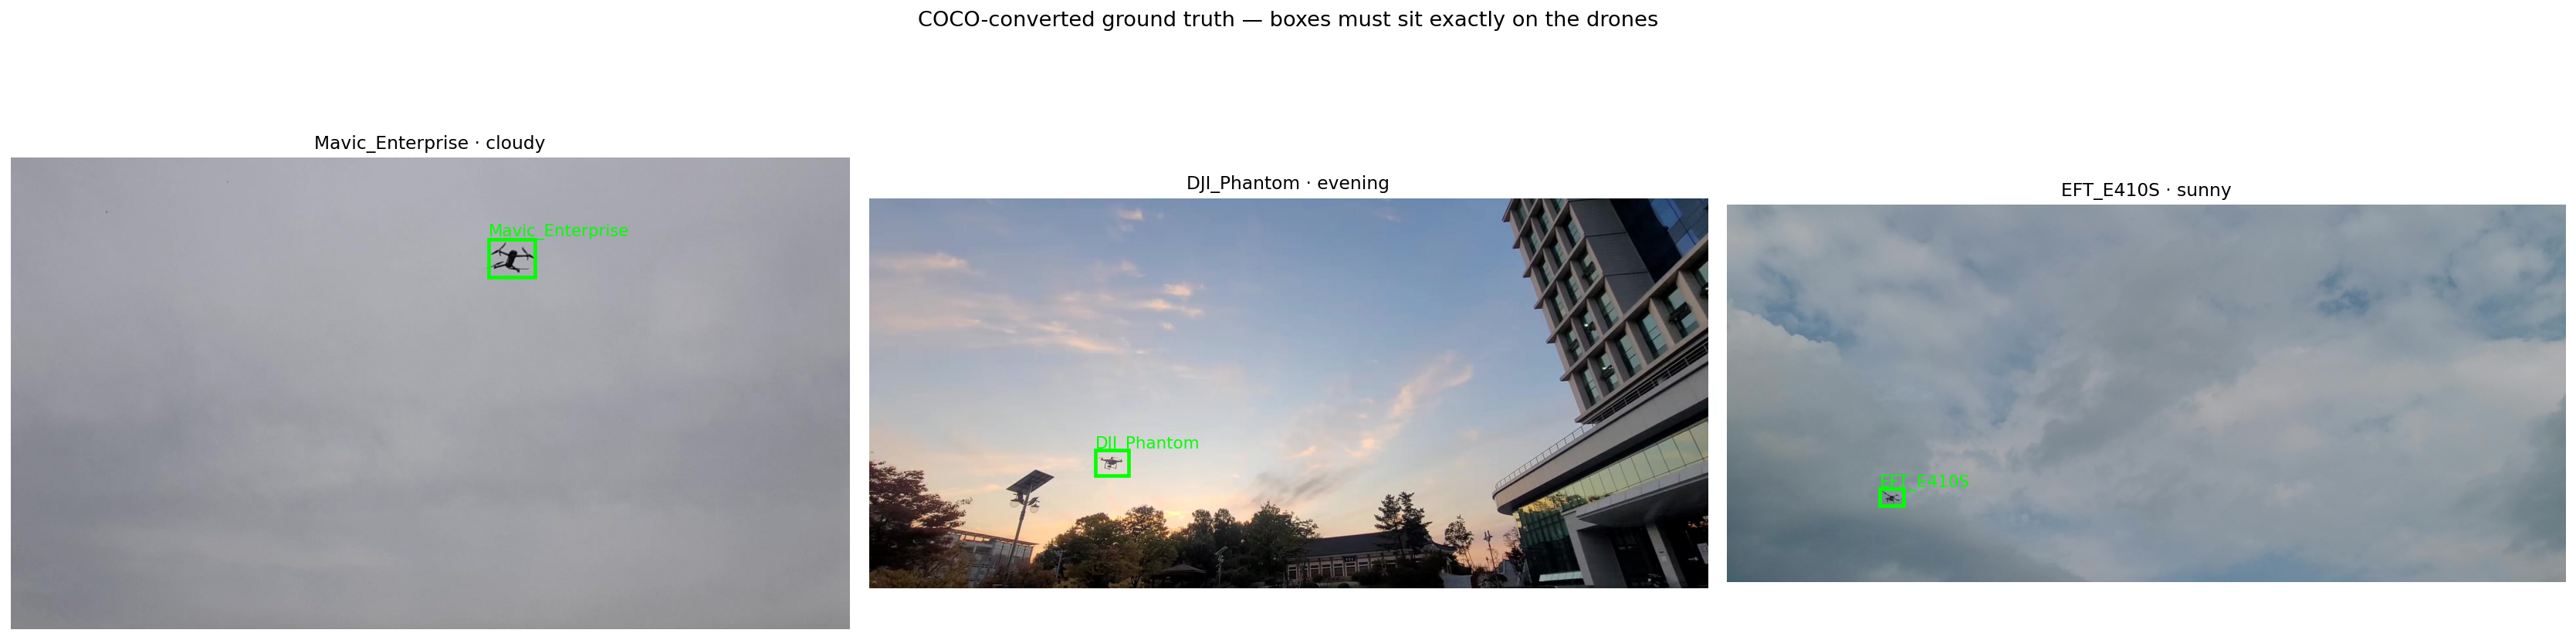

In [6]:
# ---- visual check of converted COCO annotations (one per scenario, LARGE) ----
test_json = json.loads((coco_root / "test" / "_annotations.coco.json").read_text())
by_name = {im["file_name"]: im for im in test_json["images"]}
ann_by_img = defaultdict(list)
for a in test_json["annotations"]:
    ann_by_img[a["image_id"]].append(a)

picks = (meta[meta.split == "test"].sample(frac=1, random_state=SEED)
         .groupby("scenario").head(1).sort_values("scenario"))
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, (_, r) in zip(axes, picks.iterrows()):
    info = by_name[Path(r.image).name]
    im = np.array(Image.open(coco_root / "test" / info["file_name"]).convert("RGB"))
    ax.imshow(im); ax.set_axis_off()
    for a in ann_by_img[info["id"]]:
        x, y, w, h = a["bbox"]
        ax.add_patch(mpatches.Rectangle((x, y), w, h, fill=False, edgecolor="lime", lw=2.4))
        ax.text(x, y-6, CLASS_NAMES[a["category_id"]], color="lime", fontsize=11)
    ax.set_title(f"{r.class_name} · {r.scenario}", fontsize=12)
fig.suptitle("COCO-converted ground truth — boxes must sit exactly on the drones", fontsize=14)
plt.tight_layout(); plt.show()


## 4. 1-Epoch Dry Run — Pipeline Check & Time Budget
Same protocol as the YOLO notebooks: identical batch/resolution, `epochs=1`, extrapolate
×20 against the ~9 h session (target ≤ 7 h). The dry-run model is discarded afterwards.

In [7]:
if SKIP_DRY_RUN:
    print('Dry run SKIPPED — budget already measured (see CONFIG); set SKIP_DRY_RUN=False to re-measure.')
else:
    def make_model():
        try:
            return RFDETR_CLASS(resolution=RESOLUTION)
        except Exception as e:
            raise RuntimeError(
                f"Could not initialise RF-DETR-{VARIANT} (pretrained download needs "
                f"Internet=On in Kaggle settings). Original error: {e}")
    
    def train_with_supported_kwargs(model, **kwargs):
        """Call model.train(), iteratively dropping kwargs this package version rejects
        (the course demo's version-tolerance pattern), and report what was accepted."""
        kw = dict(kwargs)
        for _ in range(len(kw)):
            try:
                model.train(**kw)
                print("train() accepted:", sorted(kw.keys()))
                return kw
            except TypeError as e:
                bad = next((k for k in list(kw) if f"'{k}'" in str(e)), None)
                if bad is None:
                    raise
                print(f"  (this rfdetr version rejects '{bad}' — dropped)")
                kw.pop(bad)
        raise RuntimeError("train() rejected every optional argument")
    
    dry = make_model()
    t0 = time.time()
    train_with_supported_kwargs(
        dry, dataset_dir=str(coco_root), output_dir=DRY_OUT, epochs=1,
        batch_size=BATCH_SIZE, grad_accum_steps=GRAD_ACCUM_STEPS, num_workers=NUM_WORKERS,
        lr=LR, lr_encoder=LR_ENCODER, clip_max_norm=CLIP_MAX_NORM,
        warmup_epochs=0, amp_dtype=AMP_DTYPE, seed=SEED)
    dry_minutes = (time.time() - t0) / 60
    est = dry_minutes * EPOCHS
    total_incl_dry = dry_minutes * (EPOCHS + 1) + 12          # + setup & evaluation
    print(f"\nDry-run epoch: {dry_minutes:.1f} min | {EPOCHS}-epoch run incl. this dry "
          f"epoch: ~{total_incl_dry:.0f} min ({total_incl_dry/60:.1f} h) of the 12 h cap")
    max_fit = int((660 - 12) / dry_minutes) - 1               # epochs fitting 11 h w/ dry
    if dry_minutes <= 29:
        print(f"✔ PROCEED with EPOCHS={EPOCHS} (assignment minimum satisfied).")
    elif EPOCHS <= max_fit:
        print(f"✔ Tight but fits: EPOCHS={EPOCHS} <= max that fits ({max_fit}). "
              "Run interactively and Quick-Save.")
    else:
        print(f"⚠ EPOCHS={EPOCHS} does NOT fit. Max fitting this speed: {max_fit}. "
              "Set EPOCHS accordingly (>=15) and DOCUMENT the reduction in CONFIG "
              "(assignment §10; cite this measured number + the diminishing "
              "EMA-mAP gains of the 11-epoch run).")
    del dry; torch.cuda.empty_cache()


[2026-07-12 14:39:19] [INFO] rf-detr - Downloading pretrained weights for /root/.roboflow/models/rf-detr-nano.pth


/root/.roboflow/models/rf-detr-nano.pth:   0%|          | 0.00/349M [00:00<?, ?iB/s]

[2026-07-12 14:39:24] [INFO] rf-detr - MD5 validation successful for /root/.roboflow/models/rf-detr-nano.pth


[2026-07-12 14:39:24] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-12 14:39:24] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-07-12 14:39:25] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


...

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/module.py:1333: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate


[2026-07-12 14:55:25] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/runs_rfdetr/rfdetr_nano_dryrun/checkpoint_best_regular.pth (epoch 0, monitor=val/mAP_50_95, value=0.539184)
[2026-07-12 14:55:25] [INFO] rf-detr - Best EMA mAP improved to 0.5477 (epoch 0)


`Trainer.fit` stopped: `max_epochs=1` reached.


[2026-07-12 14:55:28] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.5392, ema=0.5477)
train() accepted: ['amp_dtype', 'batch_size', 'clip_max_norm', 'dataset_dir', 'epochs', 'grad_accum_steps', 'lr', 'lr_encoder', 'num_workers', 'output_dir', 'seed', 'warmup_epochs']

Dry-run epoch: 16.0 min | 20-epoch run incl. this dry epoch: ~349 min (5.8 h) of the 12 h cap
✔ PROCEED with EPOCHS=20 (assignment minimum satisfied).


## 5. Full Training — 
Fresh model from the pretrained checkpoint (the dry-run epoch is discarded). The accepted
`train()` arguments are printed — cite them in the viva for the backbone-vs-head LR and
gradient-clipping questions. Loss components (classification / box-L1 / GIoU, per §6.5)
and validation mAP are then plotted from RF-DETR's own training log.

> **Augmentation note (from the measured run's log):** this rfdetr version's keypoint pipeline auto-disables `HorizontalFlip` when no keypoint flip pairs are configured — so RF-DETR trains **without** horizontal flip, unlike the YOLO notebooks (`fliplr=0.5`). A library-imposed difference worth stating in the viva when comparing augmentation configs.

In [8]:
run_out = Path(RUN_OUT)
if run_out.exists() and not RESUME:
    shutil.rmtree(run_out)
run_out.mkdir(parents=True, exist_ok=True)

rf_model = make_model()
t0 = time.time()
ACCEPTED_KW = train_with_supported_kwargs(
    rf_model, dataset_dir=str(coco_root), output_dir=str(run_out), epochs=EPOCHS,
    batch_size=BATCH_SIZE, grad_accum_steps=GRAD_ACCUM_STEPS, num_workers=NUM_WORKERS,
    lr=LR, lr_encoder=LR_ENCODER, clip_max_norm=CLIP_MAX_NORM,
    warmup_epochs=WARMUP_EPOCHS, early_stopping=EARLY_STOPPING,
    early_stopping_patience=ES_PATIENCE, amp_dtype=AMP_DTYPE,
    resume=RESUME or None, seed=SEED)
TRAIN_MINUTES = (time.time() - t0) / 60
print(f"\nTraining wall time: {TRAIN_MINUTES:.1f} min")
print("Files in output dir:", sorted(p.name for p in run_out.iterdir())[:12])
torch.cuda.empty_cache()


[2026-07-12 14:55:29] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


[2026-07-12 14:55:29] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-12 14:55:29] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-07-12 14:55:30] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


[2026-07-12 14:55:31] [WARNING] rf-detr - Pretrained weights at '/root/.roboflow/models/rf-detr-nano.pth' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.
[2026-07-12 14:55:31] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-12 14:55:31] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-07-12 14:55:33] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


...

[2026-07-12 19:10:44] [INFO] rf-detr - Best EMA mAP improved to 0.6208 (epoch 15)


Metric __rfdetr_effective_map__ improved by 0.003 >= min_delta = 0.001. New best score: 0.624


[2026-07-12 19:59:06] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/runs_rfdetr/rfdetr_nano_visiodect/checkpoint_best_regular.pth (epoch 18, monitor=val/mAP_50_95, value=0.608175)
[2026-07-12 19:59:06] [INFO] rf-detr - Best EMA mAP improved to 0.6237 (epoch 18)
[2026-07-12 20:15:08] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/runs_rfdetr/rfdetr_nano_visiodect/checkpoint_best_regular.pth (epoch 19, monitor=val/mAP_50_95, value=0.611977)


`Trainer.fit` stopped: `max_epochs=20` reached.


[2026-07-12 20:15:13] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.6120, ema=0.6237)
train() accepted: ['amp_dtype', 'batch_size', 'clip_max_norm', 'dataset_dir', 'early_stopping', 'early_stopping_patience', 'epochs', 'grad_accum_steps', 'lr', 'lr_encoder', 'num_workers', 'output_dir', 'resume', 'seed', 'warmup_epochs']

Training wall time: 319.7 min
Files in output dir: ['checkpoint_19.ckpt', 'checkpoint_9.ckpt', 'checkpoint_best_ema.pth', 'checkpoint_best_regular.pth', 'checkpoint_best_total.pth', 'events.out.tfevents.1783868134.d4104c3df3d8.23.1', 'hparams.yaml', 'last.ckpt', 'metrics.csv', 'training_config.json']


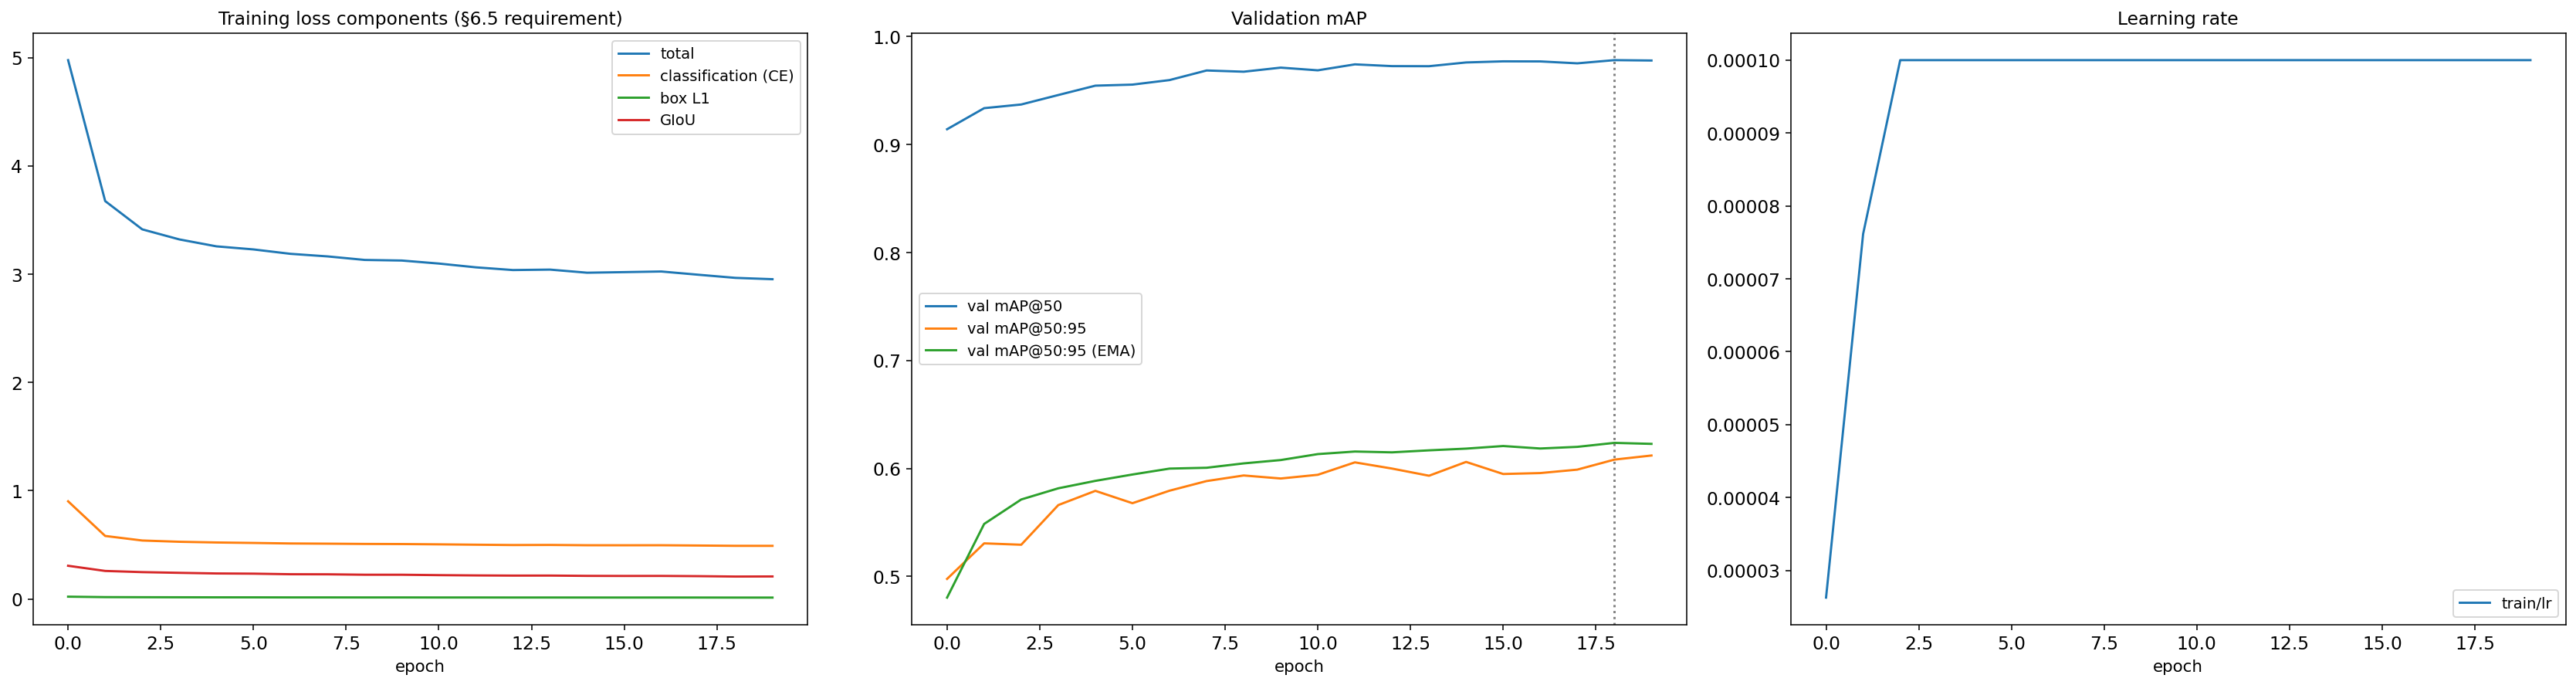

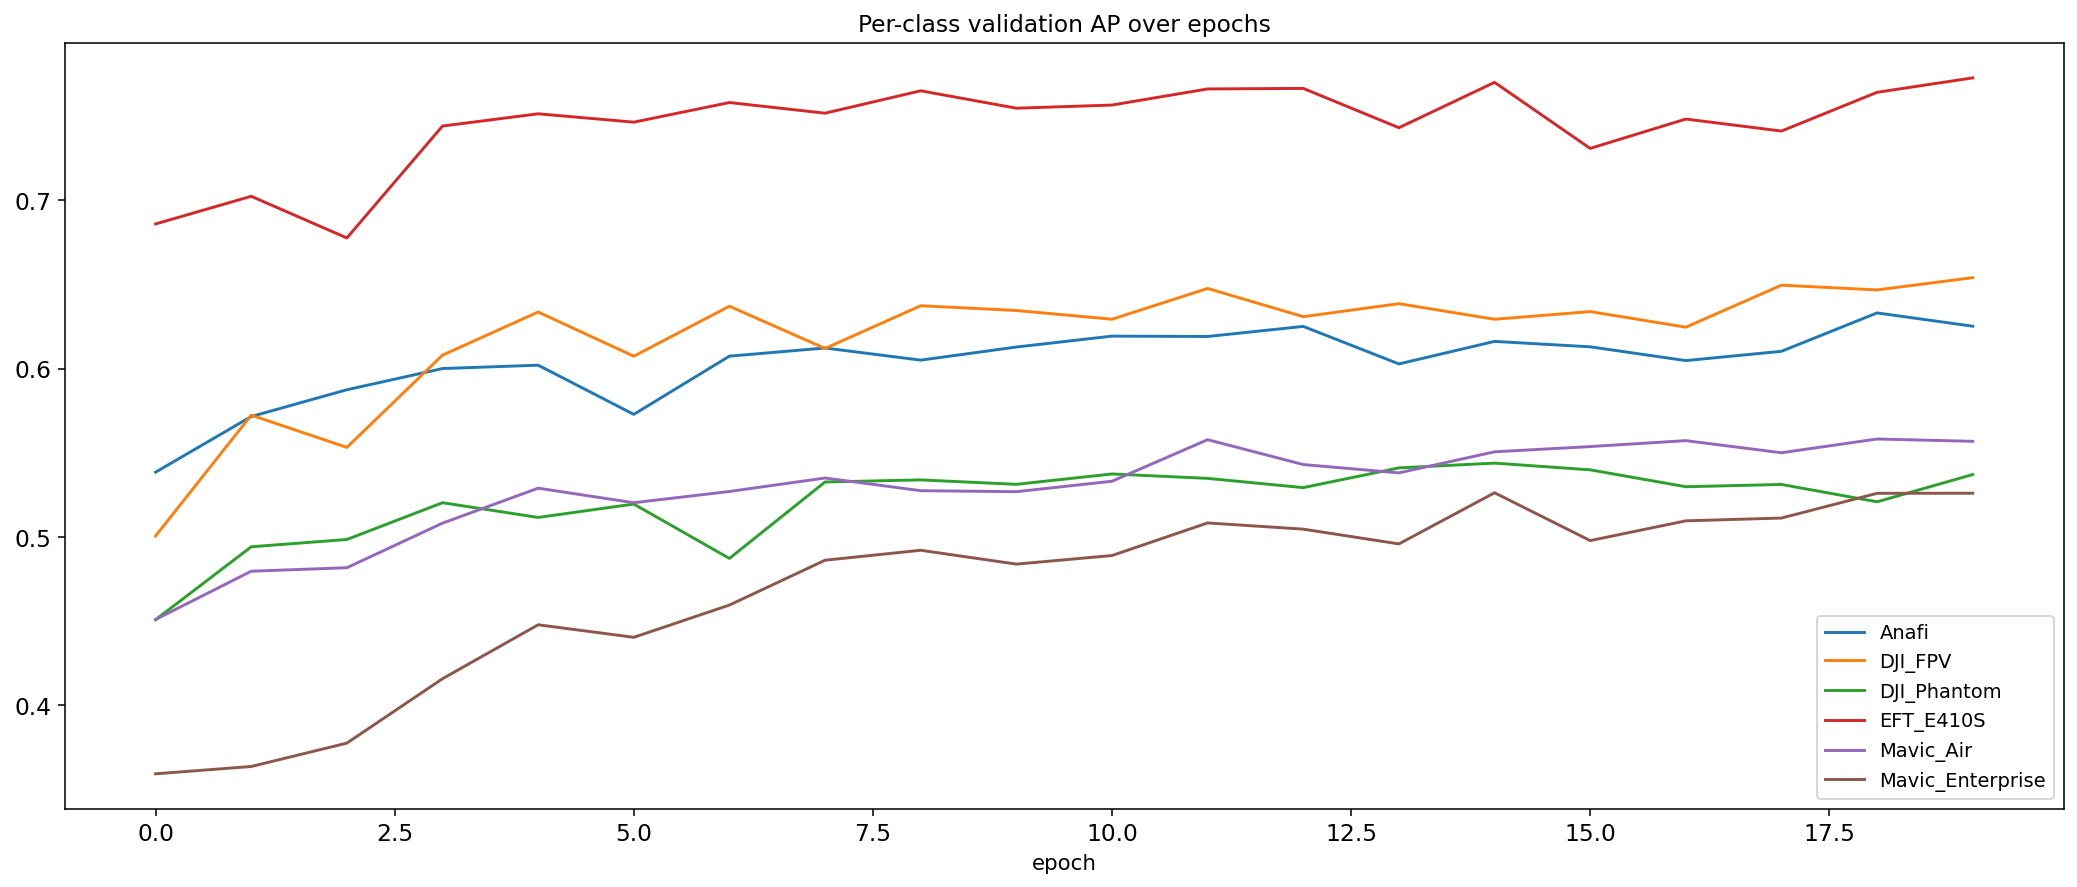

Best val mAP50-95 at epoch 18 of 19 (early stopping patience=5).


In [9]:
# ---- 5.1 training curves: Lightning metrics.csv preferred, DETR log.txt fallback
mcsv = run_out / "metrics.csv"
best_ep = EPOCHS
if mcsv.exists():
    m = pd.read_csv(mcsv)
    tr = m.groupby("epoch").mean(numeric_only=True)   # step-level rows -> per-epoch
    fig, ax = plt.subplots(1, 3, figsize=(24, 6.5))
    for k, lab in [("train/loss", "total"), ("train/loss_ce", "classification (CE)"),
                   ("train/loss_bbox", "box L1"), ("train/loss_giou", "GIoU")]:
        if k in tr:
            ax[0].plot(tr.index, tr[k], label=lab)
    ax[0].set_title("Training loss components (§6.5 requirement)"); ax[0].legend(fontsize=10)
    for k, lab in [("val/mAP_50", "val mAP@50"), ("val/mAP_50_95", "val mAP@50:95"),
                   ("val/ema_mAP_50_95", "val mAP@50:95 (EMA)")]:
        if k in tr:
            ax[1].plot(tr.index, tr[k], label=lab)
    key = "val/ema_mAP_50_95" if "val/ema_mAP_50_95" in tr.columns else "val/mAP_50_95"
    if key in tr.columns and tr[key].notna().any():
        best_ep = int(tr[key].idxmax()); ax[1].axvline(best_ep, ls=":", c="grey")
    ax[1].set_title("Validation mAP"); ax[1].legend(fontsize=10)
    if "train/lr" in tr:
        ax[2].plot(tr.index, tr["train/lr"], label="train/lr")
    ax[2].set_title("Learning rate"); ax[2].legend(fontsize=10)
    for a in ax:
        a.set_xlabel("epoch")
    plt.tight_layout(); plt.savefig(CURVES_PNG, dpi=150, bbox_inches="tight"); plt.show()

    ap_cols = [c for c in tr.columns if c.startswith("val/AP/")]
    if ap_cols:   # per-class AP trajectory: shows which drone converges slowest
        fig2, ax2 = plt.subplots(figsize=(15, 6.5))
        for c_ in ap_cols:
            ax2.plot(tr.index, tr[c_], label=c_.split("/")[-1])
        ax2.set_title("Per-class validation AP over epochs"); ax2.set_xlabel("epoch")
        ax2.legend(fontsize=10); plt.tight_layout(); plt.show()
    print(f"Best val mAP50-95 at epoch {best_ep} of {int(tr.index.max())} "
          f"(early stopping patience={ES_PATIENCE}).")
else:
    log_path = next((p for p in [run_out / "log.txt", run_out / "log.jsonl"]
                     if p.exists()), None)
    hist = []
    if log_path:
        for ln in log_path.read_text().splitlines():
            try:
                hist.append(json.loads(ln))
            except Exception:
                pass
    if hist:
        lg = pd.DataFrame(hist); lg["epoch"] = lg.get("epoch", range(len(lg)))
        fig, ax = plt.subplots(1, 2, figsize=(20, 6.5))
        for k in [k for k in ["train_loss", "train_loss_ce", "train_loss_bbox",
                              "train_loss_giou"] if k in lg]:
            ax[0].plot(lg.epoch, lg[k], label=k.replace("train_", ""))
        ax[0].set_title("Training loss components"); ax[0].legend(fontsize=10)
        ev = next((k for k in lg.columns if "coco_eval_bbox" in k), None)
        if ev is not None:
            stats = lg[ev].dropna().apply(pd.Series)
            ax[1].plot(stats.index, stats[0], label="val mAP@50:95")
            ax[1].plot(stats.index, stats[1], label="val mAP@50")
            best_ep = int(stats[0].idxmax())
        ax[1].set_title("Validation mAP"); ax[1].legend(fontsize=10)
        plt.tight_layout(); plt.savefig(CURVES_PNG, dpi=150, bbox_inches="tight"); plt.show()
        print(f"Best val mAP50-95 at epoch {best_ep}.")
    else:
        print("No metrics.csv / log.txt found in", run_out,
              "- files present:", sorted(p.name for p in run_out.iterdir()))


## 6. Test-Split Evaluation — 
Predictions are collected **once** over the whole test split at a low threshold (0.05):
COCOeval consumes the full score range for mAP@50 / mAP@50:95 and per-class AP, while
P / R / F1 at `conf=0.25` (and the later sweep) reuse the same cache. Because the demo
notes RF-DETR's predicted `class_id` can be 0- **or** 1-based depending on version, the
offset is **calibrated empirically** against ground truth before any metric is computed.

In [10]:
# ---- 6.1 one prediction sweep over the test split (threshold=CONF_PREDICT) --
def to_preds(det, offset=0):
    out = []
    if det is None:
        return out
    for b, c, s in zip(np.asarray(det.xyxy), np.asarray(det.class_id),
                       np.asarray(det.confidence)):
        out.append({"cls": int(c) + offset, "box": [float(v) for v in b],
                    "score": float(s)})
    return out

raw_cache = {}
test_all = [str(p) for p in split_imgs["test"]]
for pth in tqdm(test_all, desc="predicting test split"):
    try:
        det = rf_model.predict(pth, threshold=CONF_PREDICT)
    except TypeError:
        det = rf_model.predict(np.array(Image.open(pth).convert("RGB")),
                               threshold=CONF_PREDICT)
    raw_cache[Path(pth).name] = to_preds(det, offset=0)

# ---- 6.2 class-id offset calibration (demo-documented version variance) ------
def iou_xyxy(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / (ua + 1e-9)

def gt_for(img_path):
    lbl = Path(str(img_path).replace("/images/", "/labels/")).with_suffix(".txt")
    with Image.open(img_path) as im:
        W, H = im.size
    out = []
    for ln in lbl.read_text().splitlines():
        t = ln.split()
        if len(t) == 5:
            c, cx, cy, w, h = int(t[0]), *map(float, t[1:])
            out.append({"cls": c, "box": [(cx-w/2)*W, (cy-h/2)*H, (cx+w/2)*W, (cy+h/2)*H],
                        "area": w*W*h*H})
    return out, (W, H)

calib = Counter()
for pth in test_all[:300]:
    gt, _ = gt_for(pth)
    if not gt:
        continue
    for p in raw_cache[Path(pth).name]:
        if p["score"] < 0.3 or iou_xyxy(p["box"], gt[0]["box"]) < 0.5:
            continue
        for off in (-1, 0, 1):
            calib[off] += int(p["cls"] + off == gt[0]["cls"])
print("class-id offset votes:", dict(calib))
CLASS_OFFSET = max(calib, key=calib.get) if calib else 0
print(f"=> calibrated CLASS_OFFSET = {CLASS_OFFSET} "
      "(prediction class_id + offset == our 0-based class index)")
pred_cache = {k: [{**p, "cls": p["cls"] + CLASS_OFFSET} for p in v]
              for k, v in raw_cache.items()}
n_cls_ok = all(0 <= p["cls"] < len(CLASS_NAMES)
               for v in pred_cache.values() for p in v if p["score"] >= CONF_EVAL)
print("all confident predictions map to valid classes:", n_cls_ok)


predicting test split:   0%|          | 0/3091 [00:00<?, ?it/s]

[2026-07-12 20:15:15] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.optimize_for_inference(dtype=torch.float16).


class-id offset votes: {-1: 0, 0: 299, 1: 0}
=> calibrated CLASS_OFFSET = 0 (prediction class_id + offset == our 0-based class index)
all confident predictions map to valid classes: True


In [11]:
# ---- 6.3 COCOeval: mAP@50, mAP@50:95, per-class AP ---------------------------
coco_gt = COCO(str(coco_root / "test" / "_annotations.coco.json"))
dets = []
for pth in test_all:
    img_id = name2id["test"][Path(pth).name]
    for p in pred_cache[Path(pth).name]:
        x1, y1, x2, y2 = p["box"]
        dets.append({"image_id": img_id, "category_id": p["cls"],
                     "bbox": [x1, y1, x2-x1, y2-y1], "score": p["score"]})
coco_dt = coco_gt.loadRes(dets)
E = COCOeval(coco_gt, coco_dt, iouType="bbox")
E.evaluate(); E.accumulate(); E.summarize()
MAP5095, MAP50 = float(E.stats[0]), float(E.stats[1])

# per-class AP tables from the precision tensor [T, R, K, A, M]
prec = E.eval["precision"]
rows = []
for k, cname in enumerate(CLASS_NAMES):
    p_all  = prec[:, :, k, 0, -1]; p_50 = prec[0, :, k, 0, -1]
    rows.append({"class": cname,
                 "AP50":    round(float(p_50[p_50 > -1].mean()) if (p_50 > -1).any() else 0, 4),
                 "AP50_95": round(float(p_all[p_all > -1].mean()) if (p_all > -1).any() else 0, 4)})
per_class = pd.DataFrame(rows).sort_values("AP50_95")
display(per_class); per_class.to_csv(PER_CLASS_CSV, index=False)
print("Weakest class by AP50-95:", per_class.iloc[0]["class"],
      "-> first place to look in Section 7.")


loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.78s).
Accumulating evaluation results...
DONE (t=0.20s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.630
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.980
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.723
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.438
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.631
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.720
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.677
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.678
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

,class,AP50,AP50_95
5,Mavic_Enterprise,0.9517,0.5375
2,DJI_Phantom,0.9789,0.5661
4,Mavic_Air,0.9677,0.5771
0,Anafi,0.9900,0.6397
1,DJI_FPV,0.9898,0.6575
3,EFT_E410S,1.0000,0.8009


Weakest class by AP50-95: Mavic_Enterprise -> first place to look in Section 7.


In [12]:
# ---- 6.4 P / R / F1 at conf=0.25 (greedy IoU-0.5 matching, as in NB3/NB4 §7) -
def match(gt, preds, thr=0.50):
    used, pairs = set(), []
    for pi, pr in sorted(enumerate(preds), key=lambda x: -x[1]["score"]):
        best_i, best_g = 0, None
        for gi, g in enumerate(gt):
            if gi in used or g["cls"] != pr["cls"]:
                continue
            i = iou_xyxy(pr["box"], g["box"])
            if i > best_i:
                best_i, best_g = i, gi
        if best_g is not None and best_i >= thr:
            used.add(best_g); pairs.append((best_g, pi, best_i))
    tp = len(pairs)
    return tp, len(preds) - tp, len(gt) - tp, pairs

TP = FP = FN = 0
for pth in test_all:
    gt, _ = gt_for(pth)
    preds = [p for p in pred_cache[Path(pth).name] if p["score"] >= CONF_EVAL]
    tp, fp, fn, _ = match(gt, preds)
    TP += tp; FP += fp; FN += fn
P = TP / (TP + FP + 1e-9); R = TP / (TP + FN + 1e-9); F1 = 2*P*R/(P+R+1e-9)

summary = {"model": "RF-DETR", "variant": VARIANT, "epochs_run": EPOCHS,
           "imgsz": RESOLUTION, "batch": BATCH_SIZE * GRAD_ACCUM_STEPS,
           "precision": round(P, 4), "recall": round(R, 4), "f1": round(F1, 4),
           "mAP50": round(MAP50, 4), "mAP50_95": round(MAP5095, 4),
           "pr_source": "greedy IoU-0.5 matching @ conf 0.25 "
                        "(YOLO rows use ultralytics val P/R — note when comparing)"}
display(pd.DataFrame([summary]).drop(columns=["pr_source"]))


,model,variant,epochs_run,imgsz,batch,precision,recall,f1,mAP50,mAP50_95
0,RF-DETR,nano,20,384,16,0.9854,0.9848,0.9851,0.9797,0.6298


In [13]:
# ---- 6.5 FPS on the same hardware (single-image latency, post-warm-up) ------
warm, timed = test_all[:10], test_all[10:110]
for pth in warm:
    rf_model.predict(pth, threshold=CONF_EVAL)
t0 = time.time()
for pth in timed:
    rf_model.predict(pth, threshold=CONF_EVAL)
FPS = len(timed) / (time.time() - t0)
summary["fps_single_image"] = round(FPS, 1)
summary["train_minutes"] = round(TRAIN_MINUTES, 1)
print(f"FPS (batch=1, {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}): "
      f"{FPS:.1f}")
pd.DataFrame([summary]).to_csv(METRICS_CSV, index=False)
print("Saved:", METRICS_CSV)


FPS (batch=1, Tesla T4): 32.9
Saved: /kaggle/working/rfdetr_test_metrics.csv


### 6.6 Architecture Note — DETR vs YOLO 
RF-DETR is a **set-prediction** detector: a fixed set of object queries attends over
DINOv2-family backbone features, and training assigns each ground-truth box to exactly one
query via **bipartite (Hungarian) matching** — so duplicates are penalised *during
training* and **no NMS is needed at inference** (viva Q5). Contrast with the YOLO
notebooks: dense per-cell predictions where duplicate suppression is architectural (v26's
end-to-end head) or post-hoc. The pretrained backbone is why 20 epochs suffice where YOLO
needed 50–60 (viva Q4: DINOv2's self-supervised features transfer strongly to small
datasets). The cell below prints the parameter count for a grounded size comparison against
the YOLO summaries (YOLOv12-s printed 9.2 M / 21.2 GFLOPs; YOLOv26-s 20.4 M).

In [14]:
core = getattr(rf_model, "model", rf_model)
core = getattr(core, "model", core)
n_params = sum(p.numel() for p in core.parameters())
print(f"RF-DETR-{VARIANT} parameters: {n_params/1e6:.1f} M | resolution {RESOLUTION} "
      f"| queries: {getattr(rf_model.model_config, 'num_queries', '?') if hasattr(rf_model, 'model_config') else '?'}")
print("accepted train() args (viva evidence for lr_encoder / clip_max_norm / warmup):")
print("  ", sorted(ACCEPTED_KW.keys()))


RF-DETR-nano parameters: 30.2 M | resolution 384 | queries: 300
accepted train() args (viva evidence for lr_encoder / clip_max_norm / warmup):
   ['amp_dtype', 'batch_size', 'clip_max_norm', 'dataset_dir', 'early_stopping', 'early_stopping_patience', 'epochs', 'grad_accum_steps', 'lr', 'lr_encoder', 'num_workers', 'output_dir', 'resume', 'seed', 'warmup_epochs']


## 7. Error Analysis — 
Identical protocol to Notebooks 3/4 (greedy IoU-0.5 matching over the full test split,
scenario/class/size breakdown from the filename metadata, full-frame + zoom panels) so the
**failure patterns are directly comparable across models** — the §6.5 viva explicitly asks
for a case RF-DETR misses that YOLO detects (or vice versa): pull it from these pools vs
Notebook 3/4's saved `*_error_analysis.csv`.

In [15]:
rows = []
for img in tqdm(test_all, desc="matching"):
    gt, _ = gt_for(img)
    preds = [p for p in pred_cache[Path(img).name] if p["score"] >= CONF_EVAL]
    tp, fp, fn, _ = match(gt, preds)
    cname, scen = parse_stem(Path(img).stem)
    rows.append({"image": img, "class_name": cname, "scenario": scen,
                 "gt": len(gt), "tp": tp, "fp": fp, "fn": fn,
                 "gt_area": gt[0]["area"] if gt else np.nan})
err = pd.DataFrame(rows)
err.to_csv(ERROR_CSV, index=False)
print(f"Test frames: {len(err):,} | FN frames: {(err.fn>0).sum():,} "
      f"({(err.fn>0).mean():.2%}) | FP boxes: {err.fp.sum():,}")


matching:   0%|          | 0/3091 [00:00<?, ?it/s]

Test frames: 3,091 | FN frames: 47 (1.52%) | FP boxes: 45


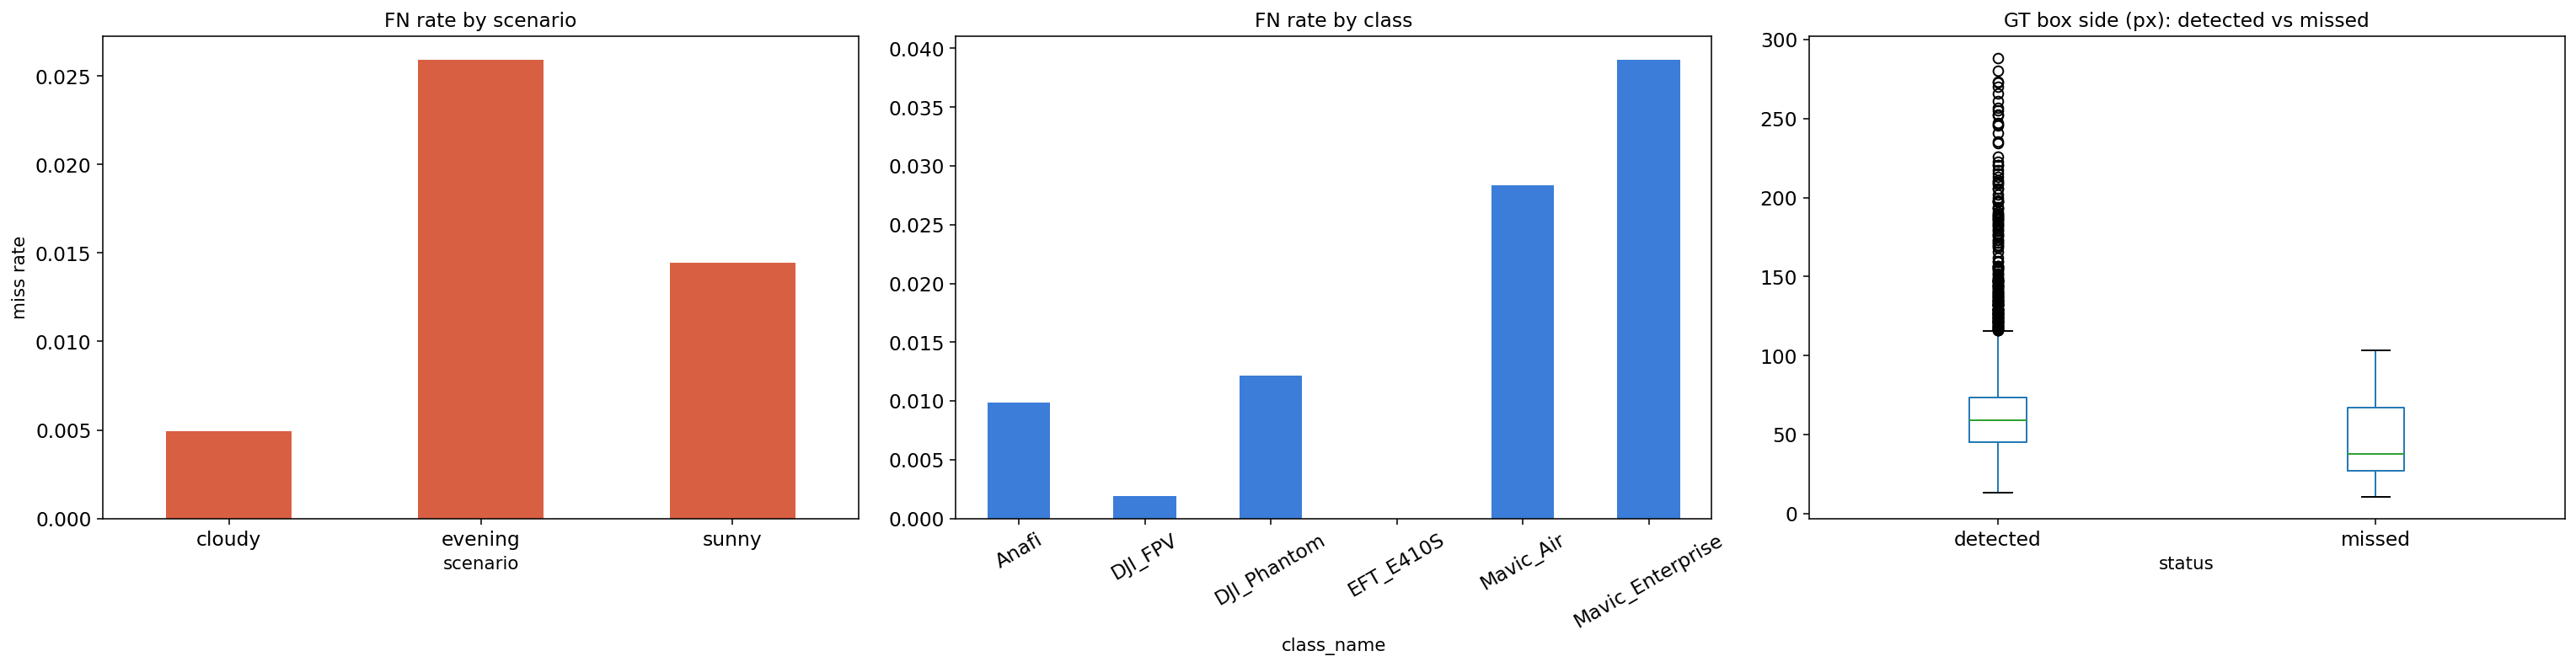

Computed failure-pattern candidate (compare with NB3/NB4's: evening / Mavic_Enterprise / small boxes):
  worst scenario : evening (2.59% miss rate)
  worst class    : Mavic_Enterprise (3.91% miss rate)
  size effect    : missed boxes are 21px smaller in median side than detected ones
Use these numbers to write the failure-pattern summary below in your own words.


In [16]:
# ---- failure-pattern breakdown: scenario, class, object size ---------------
fig, ax = plt.subplots(1, 3, figsize=(22, 6))
(err.groupby("scenario").fn.mean()).plot.bar(ax=ax[0], color="#d95f43", rot=0)
ax[0].set_title("FN rate by scenario"); ax[0].set_ylabel("miss rate")
(err.groupby("class_name").fn.mean()).plot.bar(ax=ax[1], color="#3b7dd8", rot=30)
ax[1].set_title("FN rate by class")
err["side"] = np.sqrt(err.gt_area)
err["status"] = np.where(err.fn > 0, "missed", "detected")
if err.status.nunique() > 1:
    err.boxplot(column="side", by="status", ax=ax[2], grid=False)
else:  # degenerate case (all detected or all missed)
    err.side.plot.hist(bins=30, ax=ax[2], color="#8657c2")
plt.suptitle(""); ax[2].set_title("GT box side (px): detected vs missed")
plt.tight_layout(); plt.savefig(f"{WORK_ROOT}/rfdetr_failure_breakdown.png",
                                dpi=150, bbox_inches="tight"); plt.show()

fn_scen = err.groupby("scenario").fn.mean().sort_values(ascending=False)
fn_cls  = err.groupby("class_name").fn.mean().sort_values(ascending=False)
side_gap = (err[err.fn>0]["side"].median() - err[err.fn==0]["side"].median())            if err.status.nunique() > 1 else 0.0
print("Computed failure-pattern candidate (compare with NB3/NB4's: evening / Mavic_Enterprise / small boxes):")
print(f"  worst scenario : {fn_scen.index[0]} ({fn_scen.iloc[0]:.2%} miss rate)")
print(f"  worst class    : {fn_cls.index[0]} ({fn_cls.iloc[0]:.2%} miss rate)")
print(f"  size effect    : missed boxes are {abs(side_gap):.0f}px "
      f"{'smaller' if side_gap<0 else 'larger'} in median side than detected ones")
print("Use these numbers to write the failure-pattern summary below in your own words.")


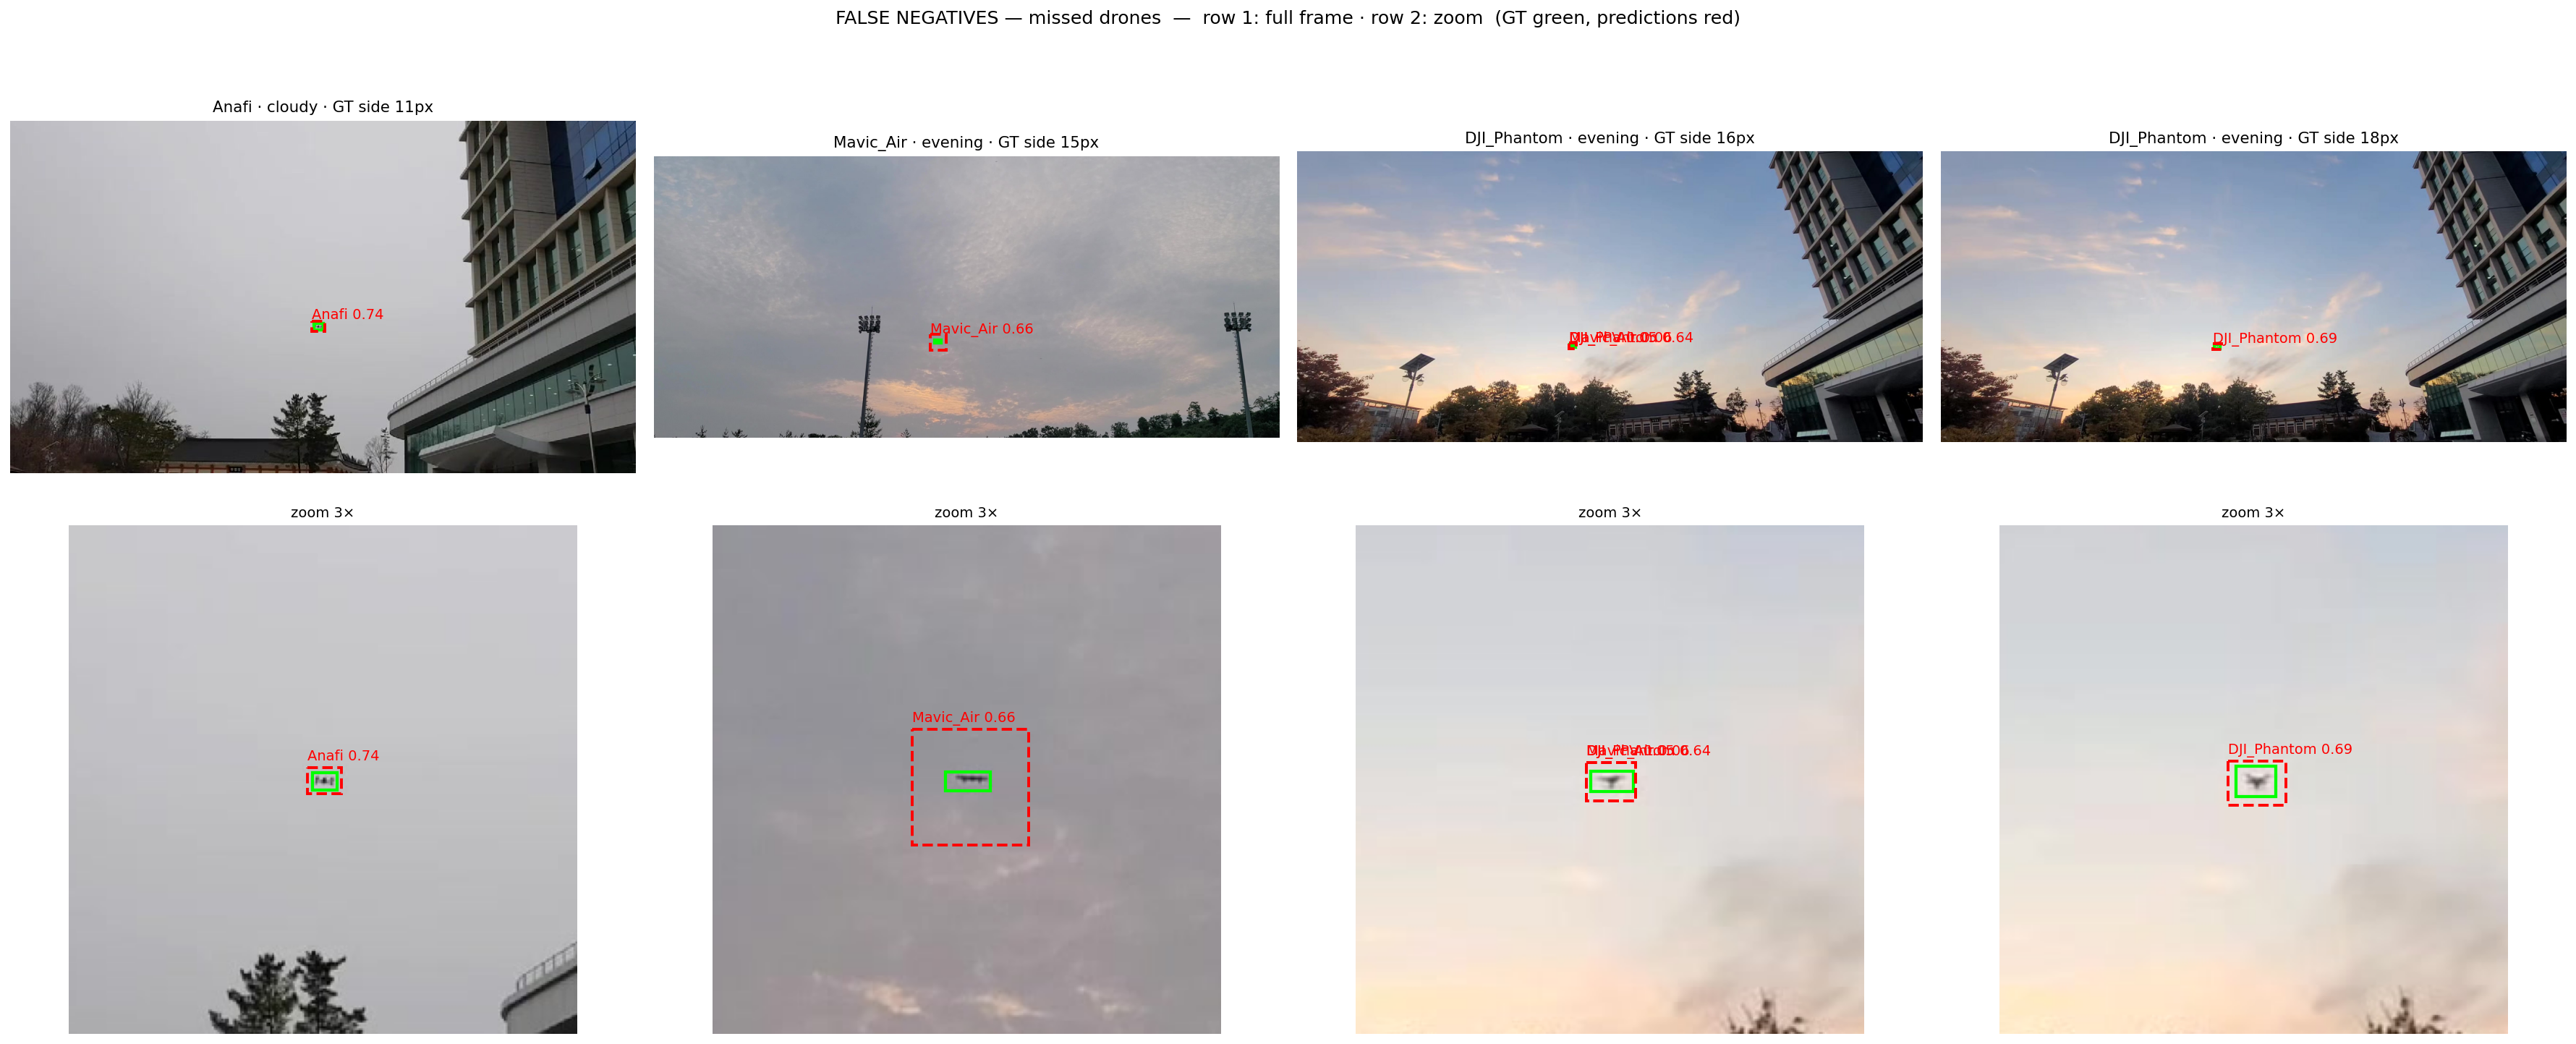

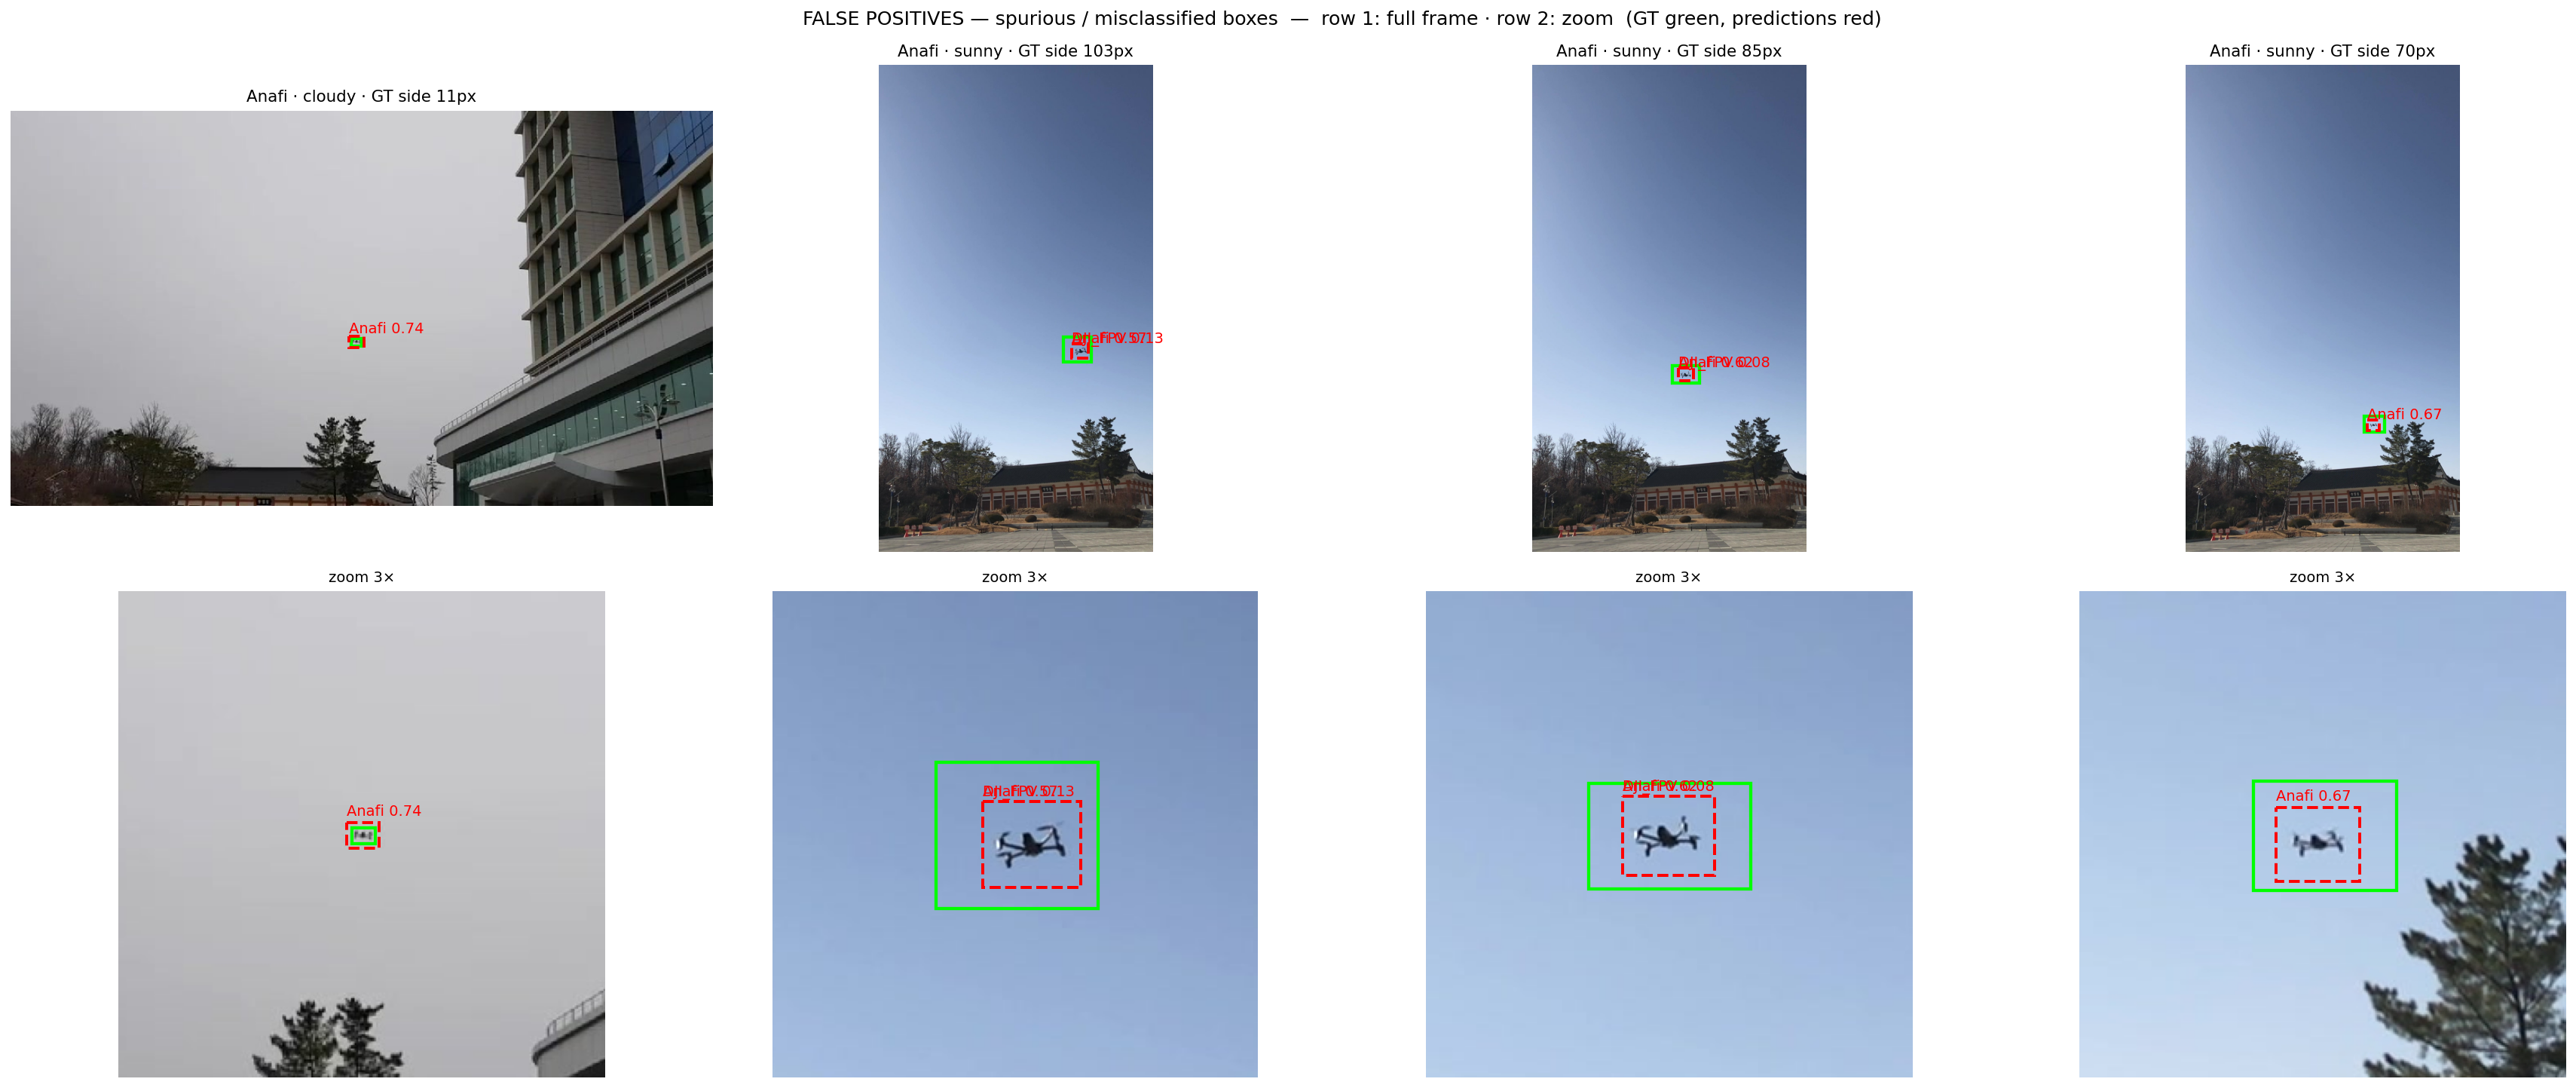

FN pool: 47 frames | FP pool: 45 frames (re-run draw_cases with .iloc slices to inspect more).


In [17]:
# ---- >=3 FN / >=3 FP: full frame + 3x ZOOM crop (drones are tiny at 2400x1080)
def zoom_window(box, W, H, factor=3.0, min_side=90):
    """Crop window centred on the box, sized so the box appears ~factor x larger."""
    x1, y1, x2, y2 = box
    cx, cy = (x1+x2)/2, (y1+y2)/2
    side = max((x2-x1), (y2-y1), min_side) * factor
    zx1, zy1 = max(0, cx-side/2), max(0, cy-side/2)
    zx2, zy2 = min(W, cx+side/2), min(H, cy+side/2)
    return int(zx1), int(zy1), int(zx2), int(zy2)

def draw_boxes_on(ax, gt, preds, off=(0, 0)):
    ox, oy = off
    for g in gt:
        x1, y1, x2, y2 = g["box"]
        ax.add_patch(mpatches.Rectangle((x1-ox, y1-oy), x2-x1, y2-y1, fill=False,
                                        edgecolor="lime", lw=2.2))
    for p in preds:
        x1, y1, x2, y2 = p["box"]
        ax.add_patch(mpatches.Rectangle((x1-ox, y1-oy), x2-x1, y2-y1, fill=False,
                                        edgecolor="red", lw=2, linestyle="--"))
        ax.text(x1-ox, y1-oy-4, f"{CLASS_NAMES[p['cls']]} {p['score']:.2f}",
                color="red", fontsize=10)

def draw_cases(frame, title, n=4, zoom=3.0):
    frame = frame.head(n)
    if frame.empty:
        print(f"{title}: no cases in this pool."); return
    fig, axes = plt.subplots(2, len(frame), figsize=(6.4*len(frame), 10.5))
    axes = np.atleast_2d(axes)
    for col, (_, r) in enumerate(frame.iterrows()):
        im = np.array(Image.open(r.image).convert("RGB")); H, W = im.shape[:2]
        gt, _ = gt_for(r.image)
        preds = pred_cache[Path(r.image).name]
        ax = axes[0, col]; ax.imshow(im); ax.set_axis_off()
        draw_boxes_on(ax, gt, preds)
        ax.set_title(f"{r.class_name} · {r.scenario} · GT side {r.side:.0f}px", fontsize=11)
        # zoom row: centre on the GT box (FN focus) or the strongest pred if no GT
        anchor = gt[0]["box"] if gt else (preds[0]["box"] if preds else [0, 0, W, H])
        zx1, zy1, zx2, zy2 = zoom_window(anchor, W, H, factor=zoom)
        axz = axes[1, col]; axz.imshow(im[zy1:zy2, zx1:zx2]); axz.set_axis_off()
        draw_boxes_on(axz, gt, preds, off=(zx1, zy1))
        axz.set_title(f"zoom {zoom:.0f}×", fontsize=10)
    fig.suptitle(title + "  —  row 1: full frame · row 2: zoom  (GT green, predictions red)",
                 fontsize=13)
    plt.tight_layout(); plt.show()

fn_cases = err[err.fn > 0].sort_values("side").reset_index(drop=True)   # hardest first
draw_cases(fn_cases, "FALSE NEGATIVES — missed drones")
fp_cases = err[err.fp > 0].sort_values("fp", ascending=False).reset_index(drop=True)
draw_cases(fp_cases, "FALSE POSITIVES — spurious / misclassified boxes")
print(f"FN pool: {len(fn_cases)} frames | FP pool: {len(fp_cases)} frames "
      "(re-run draw_cases with .iloc slices to inspect more).")


### True positives — and why "true negatives" do not exist here
The panels above cover **FN** (missed drones) and **FP** (spurious boxes). Below are **TP**
cases — correct detections with the matched IoU shown.

**True negatives are structurally undefined in object detection**: a TN would be "background
correctly not detected", but an image contains an unbounded number of background regions, so
TN cannot be counted — which is exactly why detection uses precision, recall and mAP (none of
which needs TN) rather than accuracy. On VisioDECT specifically there are also **zero
negative frames**: every test image contains a drone by construction (Notebook 1 §3.5
excluded all unannotated frames), so even a frame-level TN ("empty image, no prediction")
has no members. The closest observable notion is visible in the TP panel itself — the whole
sky and terrain around each green box is background the model correctly leaves un-boxed.

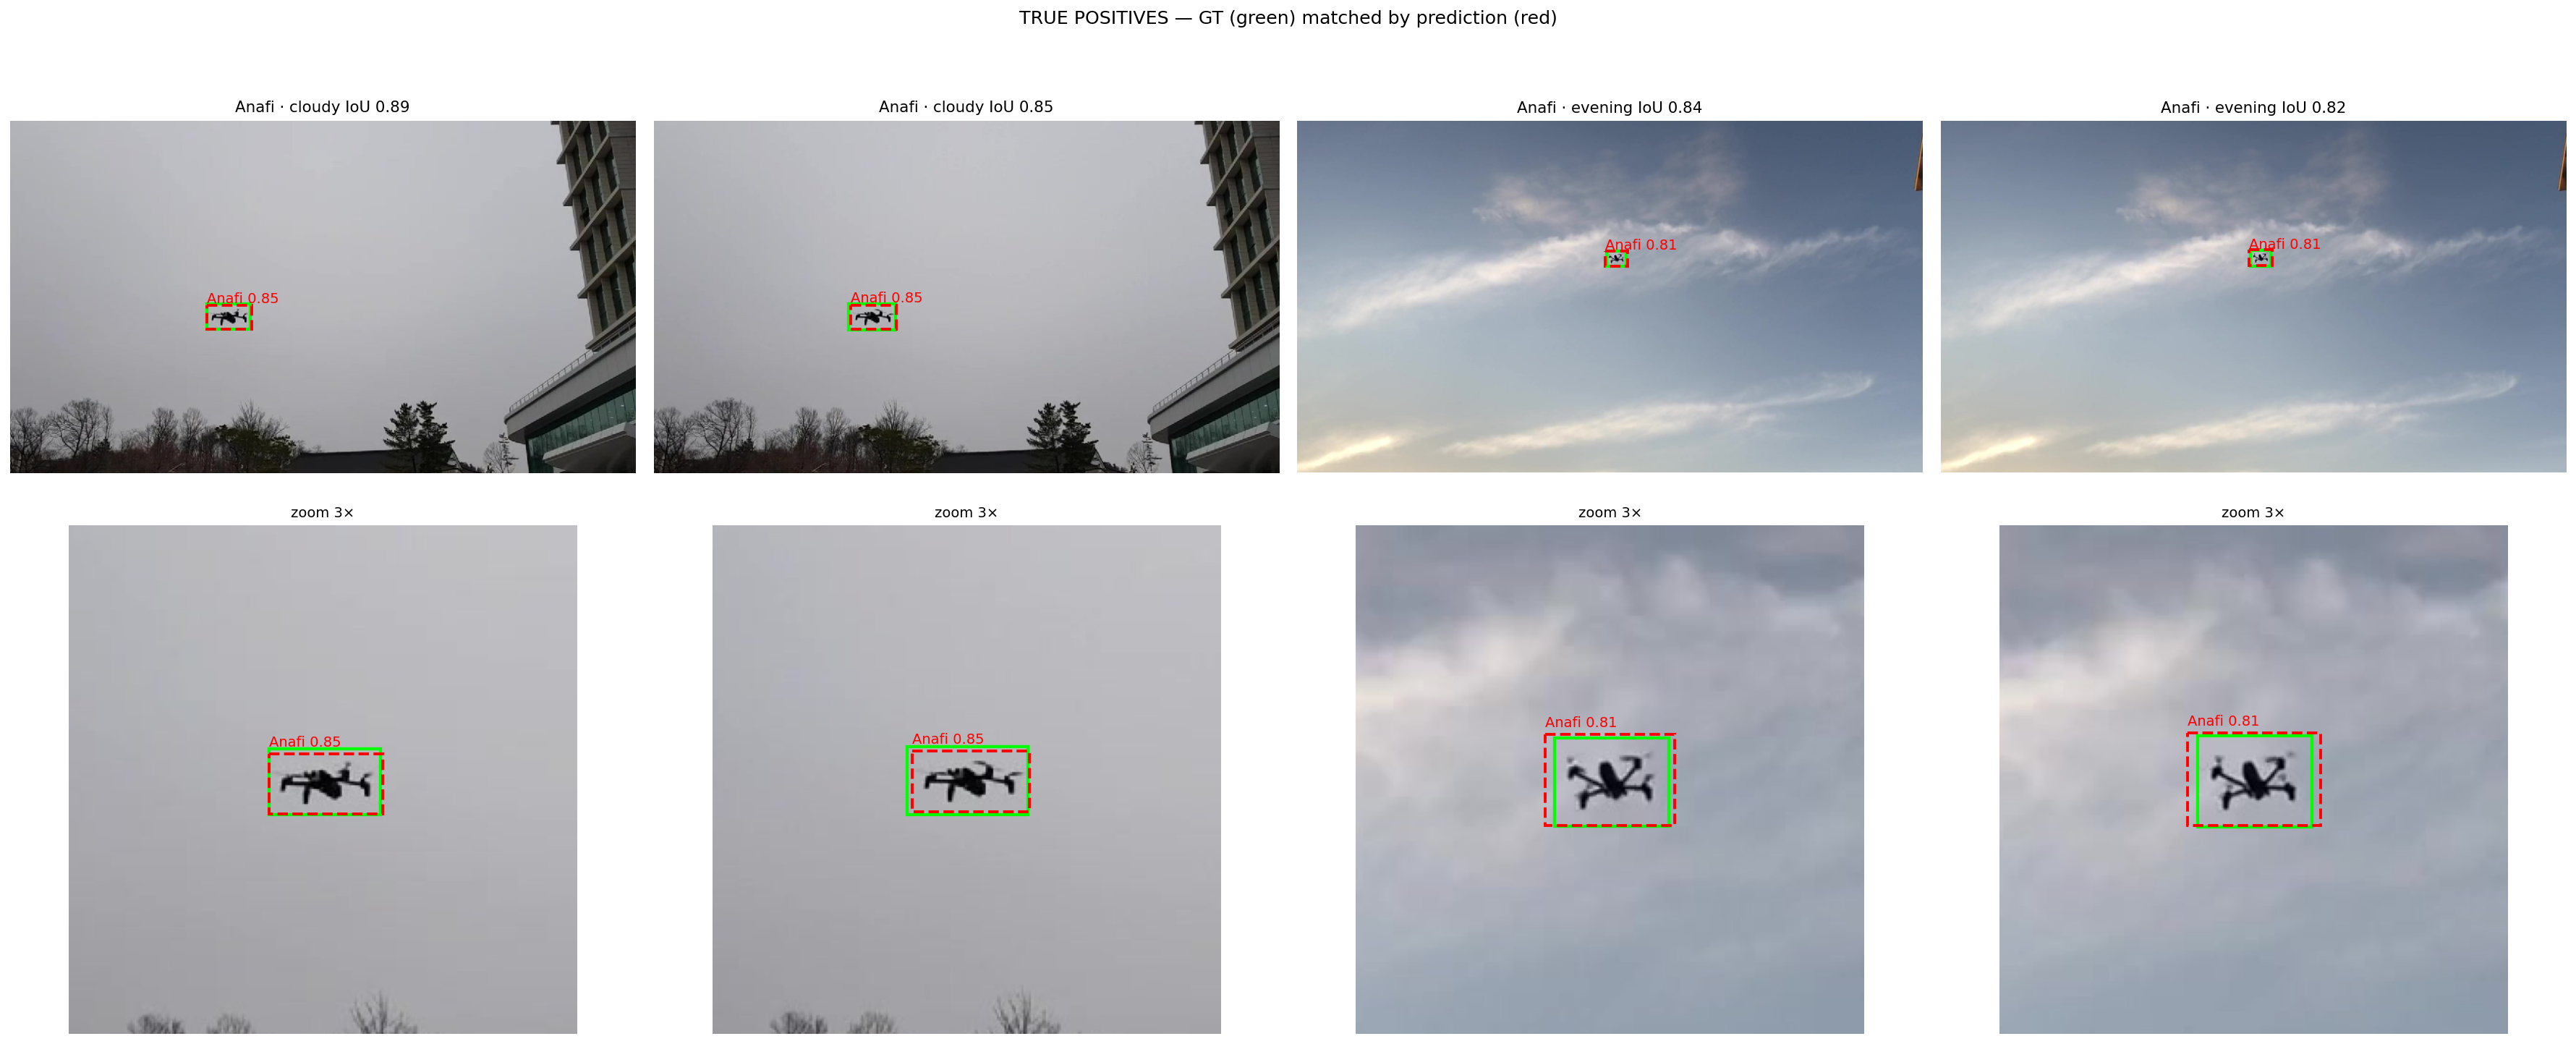

Clean-TP frames in test split: 3,045 of 3,091


In [18]:
# ---- true-positive cases (full frame + zoom, matched IoU annotated) ---------
tp_pool = err[(err.tp > 0) & (err.fp == 0)]
tp_pool = tp_pool.groupby("scenario", group_keys=False).head(2).head(4).reset_index(drop=True)
if tp_pool.empty:
    print("No clean TP frames found (unexpected on a trained model).")
else:
    fig, axes = plt.subplots(2, len(tp_pool), figsize=(6.4*len(tp_pool), 10.5))
    axes = np.atleast_2d(axes)
    for col, (_, r) in enumerate(tp_pool.iterrows()):
        im = np.array(Image.open(r.image).convert("RGB")); H, W = im.shape[:2]
        gt, _ = gt_for(r.image)
        preds = pred_cache[Path(r.image).name]
        _, _, _, pairs = match(gt, preds)
        iou_txt = f" IoU {pairs[0][2]:.2f}" if pairs else ""
        ax = axes[0, col]; ax.imshow(im); ax.set_axis_off()
        draw_boxes_on(ax, gt, preds)
        ax.set_title(f"{r.class_name} · {r.scenario}{iou_txt}", fontsize=11)
        zx1, zy1, zx2, zy2 = zoom_window(gt[0]["box"], W, H)
        axz = axes[1, col]; axz.imshow(im[zy1:zy2, zx1:zx2]); axz.set_axis_off()
        draw_boxes_on(axz, gt, preds, off=(zx1, zy1)); axz.set_title("zoom 3×", fontsize=10)
    fig.suptitle("TRUE POSITIVES — GT (green) matched by prediction (red)", fontsize=13)
    plt.tight_layout(); plt.show()
print(f"Clean-TP frames in test split: {((err.tp>0)&(err.fp==0)).sum():,} of {len(err):,}")


### 7.1 Written cause analysis 
For **each of ≥3 FN cases**: state the likely cause — e.g. *small apparent size* (check the
px side in the panel title), *low contrast against cloud/sky*, *evening under-exposure*,
*motion blur*, or *out-of-distribution pose* — and one hyperparameter/augmentation change
that could address it. For **each of ≥3 FP cases**: classify as *background object mistaken
for drone* (birds, poles, lens flare), *duplicate box*, or *cross-class confusion* (check the
red label against the folder class; the confusion matrix in §5.1 shows which drone pairs are
confused).

**Failure-pattern summary** (one paragraph, grounded in §7's computed numbers): name the one
dominant failure mode of YOLOv12-m on VisioDECT — the printed worst scenario / worst class /
size-effect line gives the evidence to cite.

### 7.2 Confidence-threshold trade-off (`conf` 0.25 → 0.50)
Recomputed from the cached low-threshold predictions — no re-inference needed.

In [19]:
sweep = []
for cth in CONF_SWEEP:
    TP = FP = FN = 0
    for img in test_all:
        gt, _ = gt_for(img)
        preds = [p for p in pred_cache[Path(img).name] if p["score"] >= cth]
        tp, fp, fn, _ = match(gt, preds)
        TP += tp; FP += fp; FN += fn
    p_ = TP / (TP + FP + 1e-9); r_ = TP / (TP + FN + 1e-9)
    sweep.append({"conf": cth, "TP": TP, "FP": FP, "FN": FN,
                  "precision": round(p_, 4), "recall": round(r_, 4),
                  "f1": round(2*p_*r_/(p_+r_+1e-9), 4)})
sweep_df = pd.DataFrame(sweep)
display(sweep_df)
sweep_df.to_csv(f"{WORK_ROOT}/rfdetr_conf_sweep.csv", index=False)
print("Expected pattern: precision rises and recall falls as conf increases — "
      "quantified here at IoU 0.5 matching.")


,conf,TP,FP,FN,precision,recall,f1
0,0.25,3045,45,47,0.9854,0.9848,0.9851
1,0.40,3045,45,47,0.9854,0.9848,0.9851
2,0.50,3044,45,48,0.9854,0.9845,0.9850


Expected pattern: precision rises and recall falls as conf increases — quantified here at IoU 0.5 matching.


## 8. Save Best Checkpoint & Comparison Artifacts
Same contract as Notebooks 3/4 so §8.1's table assembles itself:

| Artifact | Path |
|---|---|
| **Best checkpoint** | **`/kaggle/working/checkpoints/rfdetr_nano_best.pth`** (best-EMA when available) |
| Comparison record | `/kaggle/working/model_comparison/rfdetr.json` |
| Test metrics / per-class / errors / conf sweep | `rfdetr_*.csv` in `/kaggle/working/` |
| Training curves | `rfdetr_training_curves.png` |

In [20]:
Path(CKPT_PATH).parent.mkdir(parents=True, exist_ok=True)
Path(COMPARISON_JSON).parent.mkdir(parents=True, exist_ok=True)

cands = [run_out / "checkpoint_best_ema.pth", run_out / "checkpoint_best_regular.pth",
         run_out / "checkpoint_best_total.pth", run_out / "checkpoint.pth"]
best_src = next((c for c in cands if c.exists()), None)
if best_src is None:                       # fall back to any .pth in the run dir
    pths = sorted(run_out.glob("*.pth"))
    assert pths, f"no checkpoint found in {run_out}"
    best_src = pths[-1]
shutil.copy2(best_src, CKPT_PATH)

summary["best_epoch"] = best_ep
summary["checkpoint"] = CKPT_PATH
summary["checkpoint_source"] = best_src.name
summary["fn_rate_by_scenario"] = err.groupby("scenario").fn.mean().round(4).to_dict()
Path(COMPARISON_JSON).write_text(json.dumps(summary, indent=2))
print(f"BEST CHECKPOINT -> {CKPT_PATH} ({Path(CKPT_PATH).stat().st_size/1e6:.1f} MB, "
      f"from {best_src.name})")
print("COMPARISON JSON ->", COMPARISON_JSON)
print(json.dumps(summary, indent=2))


BEST CHECKPOINT -> /kaggle/working/checkpoints/rfdetr_nano_best.pth (120.9 MB, from checkpoint_best_ema.pth)
COMPARISON JSON -> /kaggle/working/model_comparison/rfdetr.json
{
  "model": "RF-DETR",
  "variant": "nano",
  "epochs_run": 20,
  "imgsz": 384,
  "batch": 16,
  "precision": 0.9854,
  "recall": 0.9848,
  "f1": 0.9851,
  "mAP50": 0.9797,
  "mAP50_95": 0.6298,
  "pr_source": "greedy IoU-0.5 matching @ conf 0.25 (YOLO rows use ultralytics val P/R \u2014 note when comparing)",
  "fps_single_image": 32.9,
  "train_minutes": 319.7,
  "best_epoch": 18,
  "checkpoint": "/kaggle/working/checkpoints/rfdetr_nano_best.pth",
  "checkpoint_source": "checkpoint_best_ema.pth",
  "fn_rate_by_scenario": {
    "cloudy": 0.0049,
    "evening": 0.0259,
    "sunny": 0.0145
  }
}


### 8.1 Cross-model comparison
Merges every `model_comparison/*.json` in this session — RF-DETR's record plus the attached
Notebook 3 (YOLOv12: mAP50-95 0.6534, 53.5 FPS) and Notebook 4 (YOLOv26: 0.6489, 67.9 FPS)
outputs. This table is the evidence base for viva Q6 (accuracy vs speed vs deployment) —
note the `pr_source` caveat when comparing P/R across the DETR and YOLO rows.

In [21]:
records = []
for j in list(Path(WORK_ROOT).glob("model_comparison/*.json")) + \
         list(Path("/kaggle/input").glob("*/model_comparison/*.json")):
    try:
        records.append(json.loads(j.read_text()))
    except Exception:
        pass
comp = pd.DataFrame(records)
cols = [c for c in ["model", "variant", "mAP50", "mAP50_95", "precision", "recall",
                    "f1", "fps_single_image", "train_minutes", "best_epoch"] if c in comp]
display(comp[cols].sort_values("mAP50_95", ascending=False)
        if "mAP50_95" in comp else comp)
print("Deployment lens for the viva: rank by mAP50-95 for accuracy, by FPS for real-time — "
      "state which you would ship and under what latency constraint.")


,model,variant,mAP50,mAP50_95,precision,recall,f1,fps_single_image,train_minutes,best_epoch
0,RF-DETR,nano,0.9797,0.6298,0.9854,0.9848,0.9851,32.9,319.7,18


Deployment lens for the viva: rank by mAP50-95 for accuracy, by FPS for real-time — state which you would ship and under what latency constraint.


## 9. Optimization Options — Discussion
- **Resolution 448 → 576/640** — DETRs are resolution-sensitive (assignment §4.3.3) and
  our median 59 px drones shrink to ~11–14 px at 448, so raising resolution targets the
  small-box FN tail directly — but the measured 640 px dry run (47+ min/epoch; attention
  is quadratic in tokens) shows this needs a bigger GPU than a T4 session offers.
- **nano → base** — stronger backbone features and a higher AP ceiling for ~2–3× compute;
  justified only if nano's validation mAP is still climbing at epoch 20 (check §5.1).
- **Longer schedule / later `lr_drop`** — DETR heads keep improving slowly; weigh against
  the T4 budget measured in §4.
- **`lr_encoder` schedule** — raising it after convergence approximates the assignment's
  unfreeze-later recipe; document any change and its curve effect.
- **Query count** — 300 queries for one drone per image is generous; reducing could raise
  FPS, but is an architecture change — discuss, don't do, within this assignment.
- **What NOT to do**: NMS tuning (bipartite matching makes it moot — viva Q5), mixup /
  vertical flip / heavy rotation (excluded with reasons in Notebook 1 §6).

## 10. Pre-Commit Checklist
- [ ] Dry-run estimate within budget; full 20-epoch run completed (or early-stopped, curve shown)
- [ ] COCO conversion table + visual check rendered; class-offset calibration printed
- [ ] COCOeval summary, per-class table, P/R/F1, FPS and conf-sweep outputs visible
- [ ] ≥3 FN, ≥3 FP and TP zoom panels rendered, cause analysis written in §7.1
- [ ] `checkpoints/rfdetr_nano_best.pth` and `model_comparison/rfdetr.json` printed their paths
- [ ] Group fields filled; *Save Version → Save & Run All*; visibility **Public**; incognito link test

